# SIGS — Neuro-Symbolic PDE Solver

This notebook walks through the full SIGS pipeline from the paper  
**"Neuro-Symbolic AI for Analytical Solutions of Differential Equations"** (arXiv:2502.01476).

**Two-stage pipeline:**
- **Stage I (§3.1):** Sample symbolic ansätze from the Grammar-VAE latent space; score by PDE residual RMSE.
- **Stage II (§3.2):** Accept the best structural form; optimize numeric coefficients via JAX autodiff + Adam.

Run cells top-to-bottom. GPU strongly recommended for Stage II.

In [14]:
# Automatically reload all modules when they change
%load_ext autoreload
    
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import jax, jax.numpy as jnp
from time import perf_counter


# Allocate on GPU
x = jnp.ones((2000, 2000))

# Verify device placement
print("x device:", x.device)
#    → should say something like “GpuDevice(id=0)”

@jax.jit
def matmul(a, b):
    return a @ b

_ = matmul(x, x).block_until_ready()   # warm-up

t0 = perf_counter()
_ = matmul(x, x).block_until_ready()
t1 = perf_counter()
print(f"2000×2000 matmul on GPU took {(t1-t0)*1000:.1f} ms")
import os, jax
os.environ.pop('JAX_PLATFORM_NAME', None)

print("jax version:", jax.__version__)
print("backend:", jax.default_backend())  # should be 'gpu'
print("devices:", jax.devices())          # should list [CudaDevice(id=0)]


x device: cuda:0
2000×2000 matmul on GPU took 2.0 ms
jax version: 0.4.33
backend: gpu
devices: [CudaDevice(id=0)]


In [13]:
# ──────────────────────────────────────────────────────────────────────────────
# Portable setup: paths, imports, device, multiprocessing (cross-platform)
# ──────────────────────────────────────────────────────────────────────────────
from pathlib import Path
import os, sys, multiprocessing as mp

def find_root(start: Path) -> Path:
    """
    Walk up from 'start' until we find the folder that contains your local modules.
    Adjust markers if your file names differ.
    """
    markers = {"src", "configs", "requirements.txt"}
    p = start.resolve()
    for cand in [p, *p.parents]:
        if all((cand / m).exists() for m in markers):
            return cand
    return start  # fallback: current directory

# If running in a notebook, Path.cwd() is the notebook directory.
NOTEBOOK_DIR = Path.cwd()
ROOT = find_root(NOTEBOOK_DIR)

# Put ROOT on sys.path so local modules can be imported
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Optionally align CWD with ROOT (only if your code expects it)
os.chdir(ROOT)
print(f"Project root: {ROOT}")

# Multiprocessing mode that's safe in notebooks and cross-platform
if mp.get_start_method(allow_none=True) != "spawn":
    try:
        mp.set_start_method("spawn", force=True)
    except RuntimeError:
        pass

# Dependencies (standard + ML)
import re, pickle, logging
from collections import Counter
from dataclasses import dataclass
from enum import Enum, auto
from functools import lru_cache
from typing import Dict, List, Optional, Set, FrozenSet
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import h5py
import yaml
import sympy as sp
import symengine as se
# from cma import CMAEvolutionStrategy as cmaES
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import seaborn as sns  # optional

# Your modules (in this folder)
from model_alltogether import GrammarVAE
from util_alltogether import GrammarVAEModel
from grammar_alltogether import GCFG, S, get_mask
from stack import Stack
from nltk import Nonterminal

from utils_submission import *
from sampler import FlexibleVectorSampler
from evaluator_vector import *
from flags_creator import *


Project root: /home/oroikon/projects/submission_files/SIGS/src/Solution/all-together



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/oroikon/miniconda3/envs/lode-dev/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/oroikon/miniconda3/envs/lode-dev/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/oroikon/miniconda3/envs/lode-dev/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/oroikon/miniconda3/envs/lode-dev/lib/python3.10/site-packages/traitlets/config/applicat

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# Paths (relative to ROOT) with environment-variable overrides
# Users can override with:
#   export LODE_CONFIG=...
#   export LODE_CKPT=...
#   export LODE_H5=...
#   export LODE_CSV=...
# ──────────────────────────────────────────────────────────────────────────────
CONFIG_PATH = Path(os.getenv("LODE_CONFIG", ROOT / "configs" / "config.yaml"))

# If the user doesn't set LODE_CKPT, try to pick the newest *.ckpt anywhere under ROOT
_ckpt_env = os.getenv("LODE_CKPT")
if _ckpt_env:
    CKPT_PATH = Path(_ckpt_env)
else:
    ckpt_candidates = sorted(ROOT.glob("**/*.ckpt"), key=lambda p: p.stat().st_mtime)
    if not ckpt_candidates:
        raise FileNotFoundError(
            "No .ckpt found under project root. Set LODE_CKPT env var or add a checkpoint."
        )
    CKPT_PATH = ckpt_candidates[-1]

H5_INPUT  = Path(os.getenv("LODE_H5",  ROOT / "data/expressions.h5"))
CSV_INPUT = Path(os.getenv("LODE_CSV", ROOT / "tsoulos_dataset_1.csv"))

print("Using config: ", CONFIG_PATH)
print("Using ckpt:   ", CKPT_PATH)
print("Using H5:     ", H5_INPUT)
print("Using CSV:    ", CSV_INPUT)


Using config:  /home/oroikon/projects/submission_files/SIGS/src/Solution/all-together/configs/config-alltogether_copy.yaml
Using ckpt:    /home/oroikon/projects/submission_files/SIGS/src/Solution/all-together/iclr_models_with_t_and_geo_loss-lower-acc-20/Wed_2025-10-15/posttopo/epochepoch=107-elboval_elbo_full=27.6547.ckpt
Using H5:      /home/oroikon/projects/submission_files/SIGS/src/Solution/all-together/iclr_final_truncated_fixed_power2_simple_t.h5
Using CSV:     /home/oroikon/projects/submission_files/SIGS/src/Solution/all-together/tsoulos_dataset_1.csv


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# Build/load decoded/flags/clusters pickles (portable)
# ──────────────────────────────────────────────────────────────────────────────
dec_pkl = ROOT / 'decoded_helm_latest_final-geo-loss-final-t.pkl'
flg_pkl = ROOT / 'expression_flags_helm_latest_final-geo-loss-final-t.pkl'
clu_pkl = ROOT / 'data/clusters.pkl'

if not clu_pkl.exists():
    dec_pkl = ensure_decoded(model, data, dec_pkl)
    flg_pkl = ensure_flags(dec_pkl, flg_pkl)
    clu_pkl = ensure_clusters(flg_pkl, clu_pkl)
    print(f"✅ Built clusters: {clu_pkl}")
else:
    print(f"✅ Found clusters: {clu_pkl}")

with open(clu_pkl, 'rb') as f:
    clusters_data = pickle.load(f)

print("Loaded clusters for classes:", list(clusters_data.keys()))


## Problem Definitions

Each problem dict encodes the PDE operator, forcing term F, mesh, IC/BCs, and the manufactured solution used to compute relative L² error.

In [16]:
# =============================================================================
# PROBLEM DEFINITIONS
# =============================================================================

def create_fixed_helmholtz_coefficient():
    """
    Create the fixed variable coefficient κ(x,y) for the Helmholtz term.
    Matches FixedRunHelmDir_like.py exactly.
    """
    import sympy as sp
    
    # Symbols
    x, y = sp.symbols('x y', real=True)
    
    # Fixed parameters from FixedRunHelmDir_like.py
    centers = [(0.35, 0.50), (0.50, 0.35)]
    amplitudes = [1.0, 1.5]
    sigmas = [0.12, 0.12]
    
    # Build sum of NEGATIVE Gaussians
    kappa_raw = 0
    for (xc, yc), A, sigma in zip(centers, amplitudes, sigmas):
        kappa_raw += -A * sp.exp(-((x - xc)**2 + (y - yc)**2) / (2 * sigma**2))
    
    # Normalization to [1,2] (approximated symbolically)
    # In practice this is done numerically after evaluation
    min_val = -2.5  # Approximate minimum (sum of amplitudes)
    max_val = 0     # Approximate maximum (far from centers)
    
    kappa_norm = (kappa_raw - min_val) / (max_val - min_val) + 1
    
    params = {
        "N": len(centers),
        "centers": centers,
        "amplitudes": amplitudes,
        "sigmas": sigmas
    }
    
    return kappa_norm, params


def create_helmholtz_problem():
    """
    Fully deterministic Helmholtz problem matching FixedRunHelmDir_like.py.
    PDE: -∇·(a∇u) + ω²κ²(x,y)u = 0
    With a(x,y) = 1 (constant diffusion coefficient)
    """
    import sympy as sp
    
    # Symbols
    x, y = sp.symbols('x y', real=True)
    
    # Frequency
    omega = 5 * sp.pi / 2
    omega_val = float(omega)
    omega_sq = (5 * sp.pi / 2) ** 2  # = 25*pi^2/4
    
    # Get kappa field
    kappa_expr, coeff_params = create_fixed_helmholtz_coefficient()
    
    # Calculate omega_sq * kappa^2 and simplify
    helmholtz_coeff = omega_sq * kappa_expr**2
    helmholtz_coeff_simplified = sp.simplify(helmholtz_coeff)
    helmholtz_coeff_str = str(helmholtz_coeff_simplified)
    
    # Fixed Dirichlet boundary value
    bc_val = 0.25
    
    problem = {
        "problem_type": "Helmholtz",
        "operators": f"- uxx - uyy + ({helmholtz_coeff_str}) * u",
        "F": "0",
        "boundary_conditions": [
            f"u(x=0, y) = {bc_val}",
            f"u(x=1, y) = {bc_val}",
            f"u(x, y=0) = {bc_val}",
            f"u(x, y=1) = {bc_val}",
        ],
        "initial_conditions": [],
        "mesh": {
            "x": {"start": 0.0, "end": 1.0, "points": 128},
            "y": {"start": 0.0, "end": 1.0, "points": 128},
        },
        "parameters": {
            # "omega": omega_val,
            # "omega_sq": float(omega_sq),
            # "bc_val": bc_val,
            # "diffusion_coeff": 1.0,
            # **coeff_params
        }
    }
    
    return problem





def create_burgers_problem():
    """Create a Burgers equation problem definition."""
    import sympy as sp

    x, t = sp.symbols('x t')
    u_L, u_R, x_0, nu = 1.46, 0.26, 0.33, 0.01
    s = (u_L + u_R) / 2
    u = (u_L + u_R) / 2 - (u_L - u_R) / 2 * sp.tanh((x - x_0 - s*t) * (u_L - u_R) / (4*nu))

    print(u)

    # Build residual
    u_t = sp.diff(u, t)
    u_x = sp.diff(u, x)
    u_xx = sp.diff(u, x, 2)
    print(f'u_t: {u_t}, u_x: {u_x}, u_xx: {u_xx}')
    F_sym = sp.simplify(u_t + u*u_x - nu*u_xx)
    F_str = str(F_sym)

    # Initial and boundary conditions
    u0 = str(sp.simplify(u.subs(t, 0)))
    left = str(sp.simplify(u.subs(x, -5)))
    right = str(sp.simplify(u.subs(x, 5)))

    return {
        "problem_type": "Burgers",
        "operators": f"ut + u*ux - {nu}*uxx",
        "F": F_str,
        "initial_condition": [f"u(x, t=0) = {u0}"],
        "boundary_conditions": [
            f"u(x=-5, t) = {left}",
            f"u(x=5, t) = {right}"
        ],
        "mesh": {
            "x": {"start": -5, "end": 5, "points": 128},
            "t": {"start": 0, "end": 2, "points": 128}
        },
        "parameters": {"nu": nu, "s": s, "u_L": u_L, "u_R": u_R, "x_0": x_0}
    }


def create_outgoing_wave_problem():
    """Create 2D outgoing wave problem with ROUNDED parameters for JAX tuning."""
    import sympy as sp

    x, y, t = sp.symbols('x y t')
    


    k = 0.5            
    omega = 0.4        
    c = omega / k       
    alpha = 0.45       
    x0 = -5.0           
    y0 = 5.0          
    
    # Additional parameters
    h = 0.2
    w = 1.1

    # Manufactured solution
    u = sp.cos(k * sp.sqrt((x - x0)**2 + (y - y0)**2) - omega * t) * sp.exp(-alpha * t)
    print(f"Exact solution: {u}")

    # Build residual for wave equation: utt - c²*(uxx + uyy) = F
    u_tt = sp.diff(u, t, 2)
    u_xx = sp.diff(u, x, 2)
    u_yy = sp.diff(u, y, 2)
    F_sym = sp.sympify(u_tt - c**2 * (u_xx + u_yy))
    F_str = str(F_sym)

    # Initial and boundary conditions
    u0 = str(sp.simplify(u.subs(t, 0)))
    
    # Boundary conditions 
    domain_min_x = x0  - 3
    domain_max_x = -x0  + 3
    domain_min_y = -y0  - 3
    domain_max_y = y0   + 3
    
    bc_xm = str(sp.simplify(u.subs(x, domain_min_x)))
    bc_xp = str(sp.simplify(u.subs(x, domain_max_x)))
    bc_ym = str(sp.simplify(u.subs(y, domain_min_y)))
    bc_yp = str(sp.simplify(u.subs(y, domain_max_y)))

    return {
        "problem_type": "Rounded Outgoing Wave for JAX Tuning",
        "operators": f"utt - {c**2}*uxx - {c**2}*uyy",  # Using c² = (ω/k)²
        "F": F_str,
        "initial_condition": [f"u(x, y, t=0) = {u0}"],
        "boundary_conditions": [
            f"u(x={domain_min_x}, y, t) = {bc_xm}",
            f"u(x={domain_max_x}, y, t) = {bc_xp}",
            f"u(x, y={domain_min_y}, t) = {bc_ym}",
            f"u(x, y={domain_max_y}, t) = {bc_yp}"
        ],
        "initial_conditions": [],
        "mesh": {
            "x": {"start": domain_min_x, "end": domain_max_x, "points": 32},
            "y": {"start": domain_min_y, "end": domain_max_y, "points": 32},
            "t": {"start": 0, "end": 4, "points": 32}
        },
        "parameters": {
            "h": h, "w": w, "k": k, "c": c, "omega": omega, "alpha": alpha, "x0": x0, "y0": y0
        }
    }

    

def create_damping_wave_problem():
    """Create 2D outgoing wave problem with ROUNDED parameters for JAX tuning."""
    import sympy as sp

    x, y, t = sp.symbols('x y t')
    


    k = 0.5            
    omega = 0.4        
    c = omega / k       
    alpha = 0.45       
    x0 = -5.0           
    y0 = 5.0          
    
    # Additional parameters
    h = 0.2
    w = 1.1

    # Manufactured solution
    u = sp.cos(k * sp.sqrt((x - x0)**2 + (y - y0)**2) - omega * t) * sp.exp(-alpha * t)
    print(f"Exact solution: {u}")

    # Build residual for wave equation: utt - c²*(uxx + uyy) = F
    u_t = sp.diff(u, t)
    u_tt = sp.diff(u, t, 2)
    u_xx = sp.diff(u, x, 2)
    u_yy = sp.diff(u, y, 2)
    F_sym = sp.sympify(u_tt + u_t- c**2 * (u_xx + u_yy))
    F_str = str(F_sym)

    # Initial and boundary conditions
    u0 = str(sp.simplify(u.subs(t, 0)))
    
    # Boundary conditions 
    domain_min_x = x0  - 3
    domain_max_x = -x0  + 3
    domain_min_y = -y0  - 3
    domain_max_y = y0   + 3
    
    bc_xm = str(sp.simplify(u.subs(x, domain_min_x)))
    bc_xp = str(sp.simplify(u.subs(x, domain_max_x)))
    bc_ym = str(sp.simplify(u.subs(y, domain_min_y)))
    bc_yp = str(sp.simplify(u.subs(y, domain_max_y)))

    return {
        "problem_type": "",
        "operators": f"utt + ut- {c**2}*uxx - {c**2}*uyy",  # Using c² = (ω/k)²
        "F": F_str,
        "initial_condition": [f"u(x, y, t=0) = {u0}"],
        "boundary_conditions": [
            f"u(x={domain_min_x}, y, t) = {bc_xm}",
            f"u(x={domain_max_x}, y, t) = {bc_xp}",
            f"u(x, y={domain_min_y}, t) = {bc_ym}",
            f"u(x, y={domain_max_y}, t) = {bc_yp}"
        ],
        "initial_conditions": [],
        "mesh": {
            "x": {"start": domain_min_x, "end": domain_max_x, "points": 32},
            "y": {"start": domain_min_y, "end": domain_max_y, "points": 32},
            "t": {"start": 0, "end": 4, "points": 32}
        },
        "parameters": {
            "h": h, "w": w, "k": k, "c": c, "omega": omega, "alpha": alpha, "x0": x0, "y0": y0
        }
    }

# import sympy as sp

def create_wave_problem():
    # Symbols
    x, t, c = sp.symbols('x t c')
    c_val = 0.14  # shared beta for all modes

    coeffs = [1.4e-1, 4.6e-3, 2.3e-4, 1.1e-4]

    # Manufactured solution: shared c for all modes
    u = (sp.pi/16)*sum(
        coeffs[n-1] * sp.sin(n*sp.pi*x) * sp.cos(c_val*n*sp.pi*t)
        for n in range(1, len(coeffs)+1)
    )
    print(f"Exact solution: {u}")
    # PDE residual for utt - c^2 uxx = F
    u_tt = sp.diff(u, t, 2)
    u_xx = sp.diff(u, x, 2)
    F_sym = u_tt - c_val**2 * u_xx
    print(f'u_tt: {u_tt}, u_xx: {u_xx}')

    # Initial & boundary conditions
    u0  = u.subs(t, 0)
    bc_xm = u.subs(x, -5)
    bc_xp = u.subs(x,  5)

    return {
        'problem_type': 'Wave1D',
        'operators': f'utt - {c_val}**2*uxx',
        'manufactured_solution': str(u),
        'F': str(F_sym),
        'initial_condition': [f"u(x, t=0) = {u0}"],
        'boundary_conditions': [
            f"u(x=-5, t) = {bc_xm}",
            f"u(x=5, t) = {bc_xp}",
        ],
        'mesh': {
            'x': {'start': -5, 'end': 5, 'points': 128},
            't': {'start':  0, 'end':  5, 'points': 128},
        },
        'parameters': {
            
        },

    }

def create_diffusion_problem():
    """Create a 1D diffusion equation problem with the specified triple‐mode solution."""
    import sympy as sp

    # Symbols
    x, t = sp.symbols('x t', real=True)

    # Updated parameters
    D = 0.697     # diffusion coefficient
    L = 1.397     # domain length
    A = 3.974     # common amplitude

    # Analytical solution u(x,t)
    u = (
        A * sp.sin(    sp.pi*x / L) * sp.exp(- (1**2 * sp.pi**2 * D * t) / L**2)
      - A * sp.sin(3 * sp.pi*x / L) * sp.exp(- (3**2 * sp.pi**2 * D * t) / L**2)
      + A * sp.sin(5 * sp.pi*x / L) * sp.exp(- (5**2 * sp.pi**2 * D * t) / L**2)
    )
    print(f"Analytical solution: {u}")

    # Compute source term F so that u_t = D u_xx + F
    u_t  = sp.diff(u, t)
    u_xx = sp.diff(u, x, 2)
    F_sym = sp.simplify(u_t - D*u_xx)
    print(f'u_t: {u_t}, u_xx: {u_xx}')
    F_str = str(F_sym) if F_sym != 0 else "0"

    # Initial condition u(x,0)
    u0 = sp.simplify(u.subs(t, 0))

    # Boundary conditions u(0,t) and u(L,t)
    bc_left  = sp.simplify(u.subs(x, 0))
    bc_right = sp.simplify(u.subs(x, L))

    return {
        "problem_type": "Diffusion-1D",
        "operators": f"ut - {D}*uxx",
        "F": F_str,
        "initial_condition": [
            f"u(x, t=0) = {u0}"
        ],
        "boundary_conditions": [
            f"u(x=0, t) = {bc_left}",
            f"u(x={L}, t) = {bc_right}"
        ],
        "mesh": {
            "x": {"start": 0, "end": L, "points": 128},
            "t": {"start": 0, "end": 1, "points": 128}
        },
        "parameters": {
            
        }
    }

def create_poisson_gauss_problem(centers=2):
    """Create a 2D Poisson-Gauss problem definition on [0,1]^2."""
    import sympy as sp

    # symbols
    x, y = sp.symbols('x y')
    if centers == 2:
        centers = [(0.3, 0.5), (0.7, 0.2)
               ]
    elif centers == 3:
        # Gaussian centers and common width (from Poseidon paper style)
        centers = [(0.3, 0.8), (0.7, 0.8), 
                (0.5, 0.2)
                ]

    elif centers == 4:
        centers = [(0.3, 0.5), (0.7, 0.4), 
                   (0.2, 0.2), (0.5, 0.8),
                   ]
    sigma = 0.1

    # build each Gaussian G_i(x,y)
    gaussians = [sp.exp(-((x - cx)**2 + (y - cy)**2) / (2 * sigma**2))
                 for cx, cy in centers]

    # forcing term f = sum of Gaussians
    f_sym = sum(gaussians)
    F_str = str(sp.simplify(-f_sym))

    return {
        "problem_type": "Poisson-Gauss",
        "operators": "uxx + uyy",
        "F": F_str,
        "boundary_conditions": [
            
            "u(x=0, y) = 0",
            "u(x=1, y) = 0", 
            "u(x, y=0) = 0",
            "u(x, y=1) = 0"
        ],
        "initial_conditions": [],
        "mesh": {
      
            "x": {"start": 0, "end": 1, "points": 100},  # Was 10
            "y": {"start": 0, "end": 1, "points": 100}   # Was 10
        },
        "parameters": {
           
        }
    }

# PROBLEM SETUP




def setup_problem(problem_type="helmholtz"):
    """Setup a specific problem type and return symbols and meshes."""
    global base_problem
    
    if problem_type.lower() == "helmholtz":
        base_problem = create_helmholtz_problem()
    elif problem_type.lower() == "burgers":
        base_problem = create_burgers_problem()
    elif problem_type.lower() == "outgoing_wave":
        base_problem = create_outgoing_wave_problem()
    elif problem_type.lower() == "wave":
        base_problem = create_wave_problem()
    elif problem_type.lower() == "diffusion":
        base_problem = create_diffusion_problem()
    elif problem_type.lower() == "poisson-gauss":
        base_problem = create_poisson_gauss_problem(centers=2)
    elif problem_type.lower() == "damping_wave":
        base_problem = create_damping_wave_problem()
    else:
        raise ValueError(f"Unknown problem type: {problem_type}")
    
    symbols, meshes = MeshUtils.setup_problem_symbols_meshes(base_problem)
    return symbols, meshes


# Initialize default problem

helmholtz_problem = create_helmholtz_problem()
helmholtz_symbols, helmholtz_meshes = setup_problem("helmholtz")
burgers_problem = create_burgers_problem()
burgers_symbols, burgers_meshes = setup_problem("burgers")
outgoing_wave_problem = create_outgoing_wave_problem()
outgoing_wave_symbols, outgoing_wave_meshes = setup_problem("outgoing_wave")
wave_problem = create_wave_problem()
wave_symbols, wave_meshes = setup_problem("wave")
diffusion_problem = create_diffusion_problem()
diffusion_symbols, diffusion_meshes = setup_problem("diffusion")
pg_2_problem = create_poisson_gauss_problem(centers=2)
pg_2_symbols, pg_2_meshes = setup_problem("poisson-gauss")
pg_3_problem = create_poisson_gauss_problem(centers=3)
pg_3_symbols, pg_3_meshes = setup_problem("poisson-gauss")
pg_4_problem = create_poisson_gauss_problem(centers=4)
pg_4_symbols, pg_4_meshes = setup_problem("poisson-gauss")
damping_wave_problem = create_damping_wave_problem()
damping_wave_symbols, damping_wave_meshes = setup_problem("damping_wave")

0.6*tanh(25.8*t - 30.0*x + 9.9) + 0.86
u_t: 15.48 - 15.48*tanh(25.8*t - 30.0*x + 9.9)**2, u_x: 18.0*tanh(25.8*t - 30.0*x + 9.9)**2 - 18.0, u_xx: 1080.0*(tanh(25.8*t - 30.0*x + 9.9)**2 - 1)*tanh(25.8*t - 30.0*x + 9.9)
0.6*tanh(25.8*t - 30.0*x + 9.9) + 0.86
u_t: 15.48 - 15.48*tanh(25.8*t - 30.0*x + 9.9)**2, u_x: 18.0*tanh(25.8*t - 30.0*x + 9.9)**2 - 18.0, u_xx: 1080.0*(tanh(25.8*t - 30.0*x + 9.9)**2 - 1)*tanh(25.8*t - 30.0*x + 9.9)
0.6*tanh(25.8*t - 30.0*x + 9.9) + 0.86
u_t: 15.48 - 15.48*tanh(25.8*t - 30.0*x + 9.9)**2, u_x: 18.0*tanh(25.8*t - 30.0*x + 9.9)**2 - 18.0, u_xx: 1080.0*(tanh(25.8*t - 30.0*x + 9.9)**2 - 1)*tanh(25.8*t - 30.0*x + 9.9)
Exact solution: exp(-0.45*t)*cos(0.4*t - 0.5*sqrt((x + 5.0)**2 + (y - 5.0)**2))
Exact solution: exp(-0.45*t)*cos(0.4*t - 0.5*sqrt((x + 5.0)**2 + (y - 5.0)**2))
Exact solution: exp(-0.45*t)*cos(0.4*t - 0.5*sqrt((x + 5.0)**2 + (y - 5.0)**2))
Exact solution: pi*(0.14*sin(pi*x)*cos(0.14*pi*t) + 0.0046*sin(2*pi*x)*cos(0.28*pi*t) + 0.00023*sin(3*pi*x)*c

In [18]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, pmap, random, device_put
import optax
import re
from tqdm import tqdm
import numpy as np
import time
from functools import partial

# CRITICAL: Enable 64-bit precision for machine-level accuracy
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")

def parse_params(expr):
    """Extract numeric literals from expression and replace with learnable parameters"""
    import re
    
    # Convert ^ to ** first
    result_expr = expr.replace('^', '**')
    
    # Find all floating point numbers with proper word boundaries
    pattern = r'(?<![a-zA-Z0-9_.])([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)(?![a-zA-Z0-9_.])'
    
    matches = []
    for match in re.finditer(pattern, result_expr):
        val_str = match.group(1)
        val = float(val_str)
        start, end = match.span()
        
        # Skip mathematical constants
        if abs(val - 3.14159265359) < 1e-10 or abs(val - 2.71828182846) < 1e-10:
            continue
            
        # Skip if it's an exponent (preceded by **)
        if start >= 2 and result_expr[start-2:start] == '**':
            continue
            
        # Skip small integers that are likely exponents (even without **)
        if val in [2.0, 3.0, 4.0, 5.0, 6.0, 0.5] and start > 0:
            # Check context around the number
            context_start = max(0, start-3)
            context_end = min(len(result_expr), end+3)
            context = result_expr[context_start:context_end]
            if '**' in context or '^' in context:
                continue
        
        matches.append((start, end, val_str, val))
    
    # Sort by position (descending) for safe replacement from right to left
    matches.sort(key=lambda x: x[0], reverse=True)
    
    param_values = []
    param_names = []
    
    # Replace from right to left to avoid index shifting
    for i, (start, end, val_str, val) in enumerate(matches):
        param_idx = len(matches) - 1 - i  # This gives proper p0, p1, p2 ordering
        param_name = f"p{param_idx}"
        
        # Handle negative numbers properly
        if val_str.startswith('-'):
            replacement = f"-{param_name}"
            param_values.insert(0, abs(val))
        else:
            replacement = param_name
            param_values.insert(0, val)
            
        param_names.insert(0, param_name)
        
        # Perform the replacement
        result_expr = result_expr[:start] + replacement + result_expr[end:]
    
    return result_expr, jnp.array(param_values, dtype=jnp.float64), param_names

def make_fn(expr, names):
    """Compile string expression into JAX function"""
    def fn(x, y, t, params):
        # Ensure float64 precision
        x, y, t = jnp.asarray(x, dtype=jnp.float64), jnp.asarray(y, dtype=jnp.float64), jnp.asarray(t, dtype=jnp.float64)
        
        # Build evaluation context
        ctx = {'x': x, 'y': y, 't': t}
        
        # Add parameters if provided
        if params is not None and names:
            params = jnp.asarray(params, dtype=jnp.float64)
            ctx.update({n: p for n, p in zip(names, params)})
        
        # Add math functions
        for f in ['sin', 'cos', 'exp', 'log', 'sqrt', 'tanh', 'sinh', 'cosh', 'abs']:
            ctx[f] = getattr(jnp, f)
        ctx['pi'] = jnp.pi
        ctx['e'] = jnp.e
        ctx['E'] = jnp.e
        
        # Handle ^ operator (convert to **)
        expr_fixed = expr.replace('^', '**')
        
        result = eval(expr_fixed, {"__builtins__": {}}, ctx)
        return jnp.asarray(result, dtype=jnp.float64)
    
    return jit(fn)

def deriv(fn, arg, order=1):
    """Create nth-order derivative function"""
    for _ in range(order):
        fn = grad(fn, argnums=arg)
    return jit(fn)
def make_residual(op, terms):
    """Build PDE residual function"""
    def R(x, y, t, params):
        # Ensure float64 precision
        x, y, t = jnp.asarray(x, dtype=jnp.float64), jnp.asarray(y, dtype=jnp.float64), jnp.asarray(t, dtype=jnp.float64)
        params = jnp.asarray(params, dtype=jnp.float64) if params is not None else None
        
        # Replace term names with function calls
        e = op
        for name, f in terms.items():
            e = re.sub(rf'\b{name}\b', f'terms["{name}"](x,y,t,params)', e)
        
        # Create evaluation context with all necessary math functions
        eval_context = {
            'terms': terms, 
            'x': x, 
            'y': y, 
            't': t, 
            'params': params, 
            'jnp': jnp,
            # Include all math functions
            'sin': jnp.sin,
            'cos': jnp.cos,
            'exp': jnp.exp,
            'log': jnp.log,
            'sqrt': jnp.sqrt,
            'tanh': jnp.tanh,
            'sinh': jnp.sinh,
            'cosh': jnp.cosh,
            'abs': jnp.abs,
            'pi': jnp.pi,
            'e': jnp.e,
            'E': jnp.e,
        }
        
        result = eval(e, {"__builtins__": {}}, eval_context)
        return jnp.asarray(result, dtype=jnp.float64)
    
    
    return jit(R)

def sample_initial_params(original_params, num_samples, std_factor=0.1, key=None):
    """Sample initial parameter values from Gaussian distributions"""
    if key is None:
        key = random.PRNGKey(42)
    
    original_params = jnp.asarray(original_params, dtype=jnp.float64)
    
    # Calculate standard deviations (fraction of parameter magnitude)
    stds = jnp.abs(original_params) * std_factor
    # Ensure minimum std to avoid degenerate sampling
    stds = jnp.maximum(stds, 1e-5)
    
    # Sample from multivariate normal
    samples = []
    for i in range(num_samples):
        key, subkey = random.split(key)
        sample = random.normal(subkey, shape=original_params.shape, dtype=jnp.float64)
        sample = original_params + sample * stds
        samples.append(sample)
    
    return jnp.stack(samples), key

@partial(jit, static_argnums=(0, 1, 2, 3, 4, 5))
def parallel_optimization_step(u_fn, loss_fn, grad_fn, opt_update, x, y, t, params_batch, opt_states):
    """Single optimization step for a batch of parameter sets"""
    

    def single_step(params, opt_state):
        g = grad_fn(params)
        updates, new_state = opt_update(g, opt_state)
        new_params = optax.apply_updates(params, updates)
        new_loss = loss_fn(new_params)
        return new_params, new_state, new_loss
    
    # Vectorize across the batch dimension
    batch_results = vmap(single_step)(params_batch, opt_states)
    return batch_results

def create_loss_function(expr, problem):
    """Create a compiled loss function for the PDE problem"""
    # Parse ansatz expression
    u_expr, _, u_names = parse_params(expr)
    u_fn = make_fn(u_expr, u_names)
    
    # Build computational mesh
    ks = list(problem['mesh'])
    rngs = [jnp.linspace(problem['mesh'][k]['start'],
                         problem['mesh'][k]['end'], 
                         problem['mesh'][k]['points'],
                         dtype=jnp.float64)
            for k in ks]
    
    mg = jnp.meshgrid(*rngs, indexing='ij')
    flat = [m.flatten() for m in mg]
    getv = lambda k: flat[ks.index(k)] if k in ks else jnp.zeros_like(flat[0], dtype=jnp.float64)
    x, y, t = getv('x'), getv('y'), getv('t')
    
    # Build derivative terms
    terms = {'u': u_fn}
    if 'x' in ks:
        terms['ux'] = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 0)
        terms['uxx'] = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 0, 2)
    if 'y' in ks:
        terms['uy'] = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 1)
        terms['uyy'] = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 1, 2)
    if 't' in ks:
        terms['ut'] = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 2)
        terms['utt'] = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 2, 2)
    
    # Build PDE residual
    R = make_residual(problem['operators'], terms)
    
    # Build forcing function
    if problem.get('F', '0').strip() != '0':
        Ffn = make_fn(problem['F'], [])
    else:
        Ffn = lambda x,y,t,p: jnp.asarray(0.0, dtype=jnp.float64)
    
    @jit
    def loss_fn(p):
        """Total loss function: PDE + IC + BC"""
        p = jnp.asarray(p, dtype=jnp.float64)
        
        # PDE residual loss
        r = vmap(lambda xx,yy,tt: R(xx,yy,tt,p))(x,y,t)
        f = vmap(lambda xx,yy,tt: Ffn(xx,yy,tt,None))(x,y,t)
        Lpde = jnp.mean((r - f)**2)
        
        # Initial condition loss
        Lic = jnp.asarray(0.0, dtype=jnp.float64)
        for cond in problem.get('initial_condition', []):
            parts = re.split(r'\)\s*=\s*', cond, maxsplit=1)
            rhs = parts[1]
            T = make_fn(rhs, [])
            t0 = jnp.zeros_like(x, dtype=jnp.float64)
            u0 = vmap(lambda xx,yy,tt: u_fn(xx,yy,tt,p))(x,y,t0)
            tv = vmap(lambda xx,yy,tt: T(xx,yy,tt,None))(x,y,t0)
            Lic += jnp.mean((u0 - tv)**2)
        
        # Boundary condition loss  
        Lbc = jnp.asarray(0.0, dtype=jnp.float64)
        for cond in problem.get('boundary_conditions', []):
            # jax_print("cond: {}", cond)
            
            
            lhs, rhs = cond.rsplit('=', 1)  # Changed from split to rsplit!
            lhs = lhs.strip()
            rhs = rhs.strip()
            # jax_print("lhs: {}, rhs: {}", lhs, rhs)
            
            
            # Check for x boundary
            m_x = re.search(r'x=([-\d.]+)', lhs)
            if m_x:
                xv = jnp.asarray(float(m_x.group(1)), dtype=jnp.float64)
                B = make_fn(rhs.strip(), [])
                xb = jnp.full_like(y, xv, dtype=jnp.float64)  # Fixed x, vary y
                yb = y  # Vary along y
                tb = jnp.zeros_like(y, dtype=jnp.float64)
                ub = vmap(lambda xx,yy,tt: u_fn(xx,yy,tt,p))(xb,yb,tb)
                tv = vmap(lambda xx,yy,tt: B(xx,yy,tt,None))(xb,yb,tb)
                Lbc += jnp.mean((ub - tv)**2)
                # jax_print("x boundary: xv={}, Lbc contribution={}", xv, jnp.mean((ub - tv)**2))
            
            # Check for y boundary
            m_y = re.search(r'y=([-\d.]+)', lhs)
            if m_y:
                yv = jnp.asarray(float(m_y.group(1)), dtype=jnp.float64)
                B = make_fn(rhs.strip(), [])
                xb = x  # Vary along x
                yb = jnp.full_like(x, yv, dtype=jnp.float64)  # Fixed y, vary x
                tb = jnp.zeros_like(x, dtype=jnp.float64)
                ub = vmap(lambda xx,yy,tt: u_fn(xx,yy,tt,p))(xb,yb,tb)
                tv = vmap(lambda xx,yy,tt: B(xx,yy,tt,None))(xb,yb,tb)
                Lbc += jnp.mean((ub - tv)**2)
                # jax_print("y boundary: yv={}, Lbc contribution={}", yv, jnp.mean((ub - tv)**2))
                
        # jax_print("PDE: {}, IC: {}, BC: {}", Lpde, Lic, Lbc)
        return Lpde + Lic + Lbc

    return loss_fn, jit(grad(loss_fn)), u_expr, u_names





def parallel_batch_optimize_pde(expr, problem, 
                               num_runs=500,
                               batch_size=50,  # Process this many runs in parallel
                               std_factor=0.1,
                               lr=1e-3, iters=1000,
                               rmse_threshold=1e-11,
                               verbose=True,
                               random_seed=42):
    """
    PARALLEL batch optimization with vectorized operations
    
    Args:
        batch_size: Number of optimizations to run in parallel (GPU memory dependent)
    """
    
    # Get original parameters
    _, original_params, param_names = parse_params(expr)
    
    if verbose:
        print(f"🚀 PARALLEL OPTIMIZATION MODE")
        print(f"Original expression: {expr}")
        print(f"Found {len(param_names)} parameters: {param_names}")
        print(f"Running {num_runs} optimizations in batches of {batch_size}")
        print(f"Expected speedup: {batch_size}x per batch!")
    
    # Sample all initial parameters
    key = random.PRNGKey(random_seed)
    all_param_samples, _ = sample_initial_params(
        original_params, num_runs, std_factor, key
    )
    
    # Create loss function (compile once, use many times)
    if verbose:
        print("📦 Compiling loss function...")
    
    start_compile = time.time()
    loss_fn, grad_fn, u_expr, u_names = create_loss_function(expr, problem)
    compile_time = time.time() - start_compile
    
    if verbose:
        print(f"✅ Compilation completed in {compile_time:.2f}s")
    
    # Storage for results
    all_results = []
    best_loss = float('inf')
    best_params = None
    best_expr = None
    
    # Process in batches
    num_batches = (num_runs + batch_size - 1) // batch_size
    
    pbar = tqdm(range(num_batches), desc="🔥 Parallel Batches", unit="batch")
    
    total_optimization_time = 0
    
    for batch_idx in pbar:
        batch_start = batch_idx * batch_size
        batch_end = min(batch_start + batch_size, num_runs)
        current_batch_size = batch_end - batch_start
        
        # Get parameter batch
        param_batch = all_param_samples[batch_start:batch_end]
        
        # Initialize optimizer states for this batch
        # opt = optax.adam(lr)
        # In parallel_batch_optimize_pde:
        opt = optax.chain(
            optax.adam(lr),
            optax.scale_by_schedule(
                optax.exponential_decay(init_value=1.0, transition_steps=100, decay_rate=0.9)
            )
        )
        opt_states = vmap(opt.init)(param_batch)
        
        # Initialize best tracking for this batch
        current_params = param_batch
        batch_best_losses = vmap(loss_fn)(current_params)
        batch_best_params = current_params.copy()
        
        batch_start_time = time.time()
        
        # Parallel optimization loop
        for iteration in range(iters):
            # Vectorized optimization step across entire batch
            gradients = vmap(grad_fn)(current_params)
            updates, opt_states = vmap(opt.update)(gradients, opt_states)
            current_params = vmap(optax.apply_updates)(current_params, updates)
            
            # Evaluate losses for entire batch
            current_losses = vmap(loss_fn)(current_params)
            
            # Update best parameters where loss improved
            improved_mask = current_losses < batch_best_losses
            batch_best_losses = jnp.where(improved_mask, current_losses, batch_best_losses)
            batch_best_params = jnp.where(improved_mask[:, None], current_params, batch_best_params)
            
            # Early stopping check (if all runs converged)
            rmse_values = jnp.sqrt(current_losses)
            if jnp.all(rmse_values < rmse_threshold):
                if verbose:
                    print(f"\nBatch {batch_idx+1} converged at iteration {iteration}")
                break
        
        batch_time = time.time() - batch_start_time
        total_optimization_time += batch_time
        
        # Store results from this batch
        for i in range(current_batch_size):
            global_idx = batch_start + i
            result = {
                'run_id': global_idx,
                'initial_params': param_batch[i],
                'final_params': batch_best_params[i],
                'final_loss': float(batch_best_losses[i]),
                'rmse': float(jnp.sqrt(batch_best_losses[i])),
                'batch_id': batch_idx
            }
            all_results.append(result)
            
            # Update global best
            if result['final_loss'] < best_loss:
                best_loss = result['final_loss']
                best_params = batch_best_params[i]
        
        # Update progress
        avg_batch_time = total_optimization_time / (batch_idx + 1)
        remaining_time = avg_batch_time * (num_batches - batch_idx - 1)
        
        pbar.set_postfix({
            'Best Loss': f"{best_loss:.2e}",
            'Batch Time': f"{batch_time:.1f}s",
            'ETA': f"{remaining_time/60:.1f}min",
            'Runs Done': f"{batch_end}/{num_runs}"
        })
    
    # Reconstruct best expression
    best_expr = u_expr
    for j, name in enumerate(reversed(u_names)):
        idx = len(u_names) - 1 - j
        best_expr = re.sub(rf'\b{name}\b', f"{best_params[idx]:.12f}", best_expr)
    best_expr = best_expr.replace('**', '^')
    
    # Sort results by loss
    all_results.sort(key=lambda x: x['final_loss'])
    
    if verbose:
        total_time = compile_time + total_optimization_time
        actual_speedup = (num_runs * avg_batch_time / batch_size) / total_time if total_time > 0 else 0
        
        print(f"\n" + "="*80)
        print("🚀 PARALLEL BATCH OPTIMIZATION RESULTS:")
        print("="*80)
        print(f"📊 PERFORMANCE STATISTICS:")
        print(f"  Compilation time: {compile_time:.2f}s")
        print(f"  Total optimization time: {total_optimization_time/60:.1f} minutes")
        print(f"  Average time per batch: {total_optimization_time/num_batches:.1f}s")
        print(f"  Theoretical max speedup: {batch_size}x")
        print(f"  Actual speedup vs sequential: ~{batch_size*0.7:.1f}x (estimated)")
        print(f"  Total time: {total_time/60:.1f} minutes")
        print(f"  Runs per minute: {num_runs/(total_time/60):.1f}")
        
        print(f"\n🎯 OPTIMIZATION RESULTS:")
        print(f"  Best Loss: {best_loss:.6e}")
        print(f"  Best RMSE: {float(jnp.sqrt(best_loss)):.6e}")
        print(f"  Best Expression: {best_expr}")
        
        # Statistics
        losses = [r['final_loss'] for r in all_results]
        print(f"\n📈 STATISTICS ACROSS {num_runs} RUNS:")
        print(f"  Mean Loss: {np.mean(losses):.6e}")
        print(f"  Std Loss:  {np.std(losses):.6e}")
        print(f"  Min Loss:  {np.min(losses):.6e}")
        print(f"  Median:    {np.percentile(losses, 50):.6e}")
        
        print(f"\n🏆 TOP 10 RESULTS:")
        for i, result in enumerate(all_results[:10]):
            print(f"  {i+1:2d}. Loss: {result['final_loss']:.6e}, RMSE: {result['rmse']:.6e}")
    
    return best_expr, best_loss, best_params, all_results

# Check GPU availability
def check_gpu():
    """Check if GPU is available and print device info"""
    try:
        devices = jax.devices()
        print(f"Available devices: {devices}")
        print(f"Default device: {jax.devices()[0]}")
        device_str = str(jax.devices()[0])
        if 'cuda' in device_str.lower() or 'gpu' in device_str.lower():
            print("✅ GPU detected and will be used!")
            return True
        else:
            print("⚠️  Using CPU (GPU not detected)")
            return False
    except:
        print("Could not detect devices")
        return False

# Example usage
if __name__ == "__main__":
    # Check GPU availability
    is_gpu = check_gpu()
    

Available devices: [CudaDevice(id=0)]
Default device: cuda:0
✅ GPU detected and will be used!


## Stage I — Grammar-VAE Sampler

Load the pre-trained Grammar-VAE and the pre-computed cluster database (`data/clusters.pkl`).
The sampler draws latent vectors from MathClass-specific k-means subclusters and decodes them
into syntactically valid symbolic expressions (§3.1, Algorithm 1).

In [19]:
# 2) Instantiate sampler
sampler = FlexibleVectorSampler('data/clusters.pkl',model=model,device=device)

  - SPATIAL_1D: 5536 vectors
  - CONSTANT: 567 vectors
  - SPATIAL_2D: 3848 vectors
  - SPATIOTEMPORAL_3D: 1592 vectors
  - TEMPORAL_1D: 4585 vectors
  - SPATIOTEMPORAL_2D: 7563 vectors
  - ERROR: 4 vectors


## 1-D Burgers Equation  `u_t + u·u_x − ν·u_xx = F`

**Stage I:** `sample_from_subclusters` draws candidates from SPATIOTEMPORAL_2D + CONSTANT clusters.  
**Ansatz class:** expressions in (x, t) that match the travelling-wave / shock structure.  
**Stage II:** JAX Adam refines the numeric coefficients to PDE residual RMSE ≈ 10⁻¹³.

In [41]:

# 3) Coarse sampling
categories = {   MathClass.SPATIOTEMPORAL_2D: 5,MathClass.CONSTANT: 1 }
initial_id = sampler.sample_from_subclusters(
    categories=categories,
    n_samples=5000,
    operator='-',
    seed=42,
    model=model
)

# 4) Retrieve and inspect
exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(initial_id)
print(initial_id, "initial_sample_id")
# print(sub_idxs, "subcluster_indices")
len(expr_idxs)


# 1) Filter by first constant  
filtered = ExpressionUtils.filter_by_first_const(exprs, min_val=0.1) 
local_idxs, filtered_exprs = zip(*filtered)  
all_conditions = burgers_problem.get("initial_condition", []) + burgers_problem.get("boundary_conditions", [])

# 2) Physics-based evaluation  
best_loc, best_expr, *_ = find_best_composed(
    list(ExpressionUtils.negate_and_flip_expressions(filtered_exprs)),
    operator=burgers_problem['operators'],
    F=burgers_problem['F'],
    initial_conditions=all_conditions,
    param_map=burgers_problem['parameters'],
    symbols=burgers_symbols,
    meshes=burgers_meshes,
    weight=1.0,
    rmse_threshold=3e-1
)


1 initial_sample_id
Evaluating 2377 expressions...
First 3 expressions: ['-((((1.566-0.566)/2)*tanh(((x-0.936-0.966*t)*(1.566-0.366))/(4*0.466)))) + (((0.158+2.699)/2))', '-((((2.002+0.999)/2)*tanh(((x+0.299-0.136*t)*(2.002+0.999))/(4*0.127)))) + ((4.4*-97))', '-((((2.125-0.529)/2)*tanh(((x+0.535-1.55*t)*(2.159-0.599))/(4*0.89)))) + (((-0.204+1.37)/2))']
Operator: ut + u*ux - 0.01*uxx
F: -1.77635683940025e-15*tanh(25.8*t - 30.0*x + 9.9)**3 + 1.77635683940025e-15*tanh(25.8*t - 30.0*x + 9.9)
Symbols: {'x': x, 't': t}
Using 10 processes for parallel evaluation


Evaluating expressions:   3%|▎         | 69/2377 [00:06<03:14, 11.84expr/s]  

Best loss: 1.218862 for expression: -((((1.566-0.566)/2)*tanh(((x-0.936-0.966*t)*(1.566-0.366))/(4*0.466)))) + (((0.158+2.699)/2))
Best loss: 0.761252 for expression: -((((2.125-0.529)/2)*tanh(((x+0.535-1.55*t)*(2.159-0.599))/(4*0.89)))) + (((-0.204+1.37)/2))
Best loss: 0.711540 for expression: -((((1.37+0.304)/2)*tanh(((x+0.508-1.106*t)*(1.17+0.288))/(4*0.344)))) + (((0.177+1.506)/2))
Best loss: 0.706735 for expression: -((((1.316-0.814)/2)*tanh(((x+0.435-0.711*t)*(1.316-0.841))/(4*0.411)))) + (((0.366+1.663)/2))
Best loss: 0.694651 for expression: -((((1.076-0.444)/2)*tanh(((x-0.09-0.458*t)*(1.075-0.454))/(4*0.944)))) + (((0.507+2.044)/2))
Best loss: 0.520579 for expression: -((((1.659-0.458)/2)*tanh(((x-0.799-1.599*t)*(1.759-0.458))/(4*0.75)))) + (((-0.208+2.172)/2))
Best loss: 0.427940 for expression: -((((1.45-0.448)/2)*tanh(((x-0.111-1.722*t)*(1.45-0.455))/(4*0.785)))) + (((0.474+1.456)/2))
Best loss: 0.340682 for expression: -((((1.869-0.778)/2)*tanh(((x-0.192-1.258*t)*(1.869-0.

Evaluating expressions:   6%|▌         | 141/2377 [00:06<01:45, 21.25expr/s]


Best loss: 0.278981 for expression: -((((1.784-0.771)/2)*tanh(((x-0.415-0.991*t)*(1.784-0.711))/(4*0.11)))) + (((0.057+1.722)/2))


In [148]:
import time
import re
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, random
import optax
import numpy as np

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")

# ============================================================
# 1) COMMON HELPERS: true solution + relative L2
# ============================================================

def make_true_solution_fn(expr_str):
    """
    Compile manufactured solution string into a JAX function U(x,y,t).
    For 1D problems we ignore y (call with y=0.0).
    """
    expr = expr_str.replace("^", "**")

    def fn(x, y, t):
        ctx = {"x": x, "y": y, "t": t}
        for f in ['sin', 'cos', 'exp', 'log', 'sqrt', 'tanh', 'sinh', 'cosh', 'abs']:
            ctx[f] = getattr(jnp, f)
        ctx['pi'] = jnp.pi
        ctx['e']  = jnp.e
        ctx['E']  = jnp.e
        return eval(expr, {"__builtins__": {}}, ctx)

    return jit(fn)


def compute_relative_L2(u_pred, u_true):
    """
    Relative L2 error ||u_pred - u_true||_2 / ||u_true||_2.
    """
    num = jnp.sqrt(jnp.mean((u_pred - u_true) ** 2))
    den = jnp.sqrt(jnp.mean(u_true ** 2))
    return num / (den + 1e-15)


# ============================================================
# 2) BUILD PDE-RMSE LOSS + relL2 MONITOR FOR BURGERS
# ============================================================

def create_burgers_pde_and_relL2_functions(expr, problem):
    """
    Build:
      - pde_loss_fn(params): RMSE of Burgers residual over mesh
      - pde_grad_fn(params): grad wrt params (JAX)
      - relL2_fn(params): relative L2 vs manufactured solution (NO grad use)
    
    Burgers PDE assumed:
        u_t + u * u_x - nu * u_xx = F(x,t)
    with nu read from problem["parameters"]["nu"] or problem["nu"], and
    F taken from problem["F"] (string).
    """
    # Parse symbolic ansatz -> parametric JAX function
    u_expr, init_vals, u_names = parse_params(expr)
    u_fn = make_fn(u_expr, u_names)  # expects u_fn(x, y, t, params)

    # Manufactured solution (for relL2)
    true_expr = problem.get("manufactured_solution", None)
    if true_expr is None:
        raise ValueError("burgers_problem must contain 'manufactured_solution' for relL2 monitoring.")
    U_true_fn = make_true_solution_fn(true_expr)

    # Forcing term F(x,t)
    F_expr_str = problem.get("F", "0")
    F_fn = make_true_solution_fn(F_expr_str)

    # Mesh: 1D in x and t
    mx = problem["mesh"]["x"]
    mt = problem["mesh"]["t"]
    xs = jnp.linspace(mx["start"], mx["end"], mx["points"], dtype=jnp.float64)
    ts = jnp.linspace(mt["start"], mt["end"], mt["points"], dtype=jnp.float64)
    X, T = jnp.meshgrid(xs, ts, indexing="ij")
    x_flat = X.flatten()
    t_flat = T.flatten()

    # Dummy y=0 for 1D problem
    y_flat = jnp.zeros_like(x_flat)

    # Viscosity nu
    nu = None
    if "parameters" in problem and isinstance(problem["parameters"], dict):
        nu = problem["parameters"].get("nu", None)
    if nu is None:
        nu = problem.get("nu", 0.01)
    nu = float(nu)

    # Scalar u(x,t; p) using u_fn(x, y=0, t, p)
    def u_scalar(x, t, params):
        return u_fn(x, 0.0, t, params)

    # Burgers residual at one point
    def residual_point(xx, tt, params):
        uu = u_scalar(xx, tt, params)
        ux = grad(u_scalar, 0)(xx, tt, params)
        ut = grad(u_scalar, 1)(xx, tt, params)
        uxx = grad(lambda s, tau, pp: grad(u_scalar, 0)(s, tau, pp), 0)(xx, tt, params)
        F_val = F_fn(xx, 0.0, tt)
        return ut + uu * ux - nu * uxx - F_val

    residual_point_vmapped = jit(
        vmap(lambda xx, tt, params: residual_point(xx, tt, params),
             in_axes=(0, 0, None))
    )

    @jit
    def pde_loss_fn(params):
        """
        PDE objective: RMSE of Burgers residual r(x,t; params).
        This is the ONLY quantity used for gradients.
        """
        params = jnp.asarray(params, dtype=jnp.float64)
        r = residual_point_vmapped(x_flat, t_flat, params)
        return jnp.sqrt(jnp.mean(r**2))

    pde_grad_fn = jit(grad(pde_loss_fn))

    @jit
    def relL2_fn(params):
        """
        Relative L2 vs manufactured solution on the same mesh.
        Used ONLY for monitoring + early stopping (no gradients).
        """
        params = jnp.asarray(params, dtype=jnp.float64)
        u_pred = vmap(lambda xx, tt: u_scalar(xx, tt, params))(x_flat, t_flat)
        u_true = vmap(lambda xx, tt: U_true_fn(xx, 0.0, tt))(x_flat, t_flat)
        return compute_relative_L2(u_pred, u_true)

    return pde_loss_fn, pde_grad_fn, relL2_fn, u_expr, u_names, init_vals


# ============================================================
# 3) PARAMETER INITIALIZATION FOR MULTI-RUN OPTIMIZATION
# ============================================================

def sample_initial_params_burgers(original_params, num_runs, std_factor, key):
    """
    Simple multiplicative Gaussian perturbation around original_params
    to create num_runs different initializations.
    """
    original_params = jnp.asarray(original_params, dtype=jnp.float64)
    dim = original_params.shape[0]

    key, subkey = random.split(key)
    noise = random.normal(subkey, shape=(num_runs, dim))

    # Scale noise by |param| (or 1 if param ~ 0)
    scale = std_factor * jnp.where(jnp.abs(original_params) > 1e-12,
                                   jnp.abs(original_params),
                                   1.0)
    samples = original_params + noise * scale
    return samples, key


# ============================================================
# 4) PARALLEL BURGERS OPTIMIZATION: PDE RMSE + relL2 EARLY STOP
# ============================================================

def parallel_batch_optimize_burgers_PDE_rmse_with_relL2(
    expr,
    problem,
    num_runs=100,
    batch_size=50,
    std_factor=0.1,
    lr=5e-2,
    iters=500,
    rel_threshold=9e-3,
    verbose=True,
    random_seed=123,
):
    """
    PARALLEL JAX optimization for Burgers:

    - Objective for gradients: PDE RMSE (residual of Burgers).
    - Relative L2: ONLY for monitoring + EARLY STOP (no gradient influence).

    Returns:
        best_expr_str, best_pde_loss, best_relL2, best_params, all_results
    """
    # Build PDE & relL2 functions
    pde_loss_fn, pde_grad_fn, relL2_fn, u_expr, u_names, original_params = \
        create_burgers_pde_and_relL2_functions(expr, problem)

    total_pde_evals = 0
    total_rel_evals = 0

    # Sample initial params
    key = random.PRNGKey(random_seed)
    all_param_samples, key = sample_initial_params_burgers(
        original_params, num_runs, std_factor, key
    )

    if verbose:
        print(" PARALLEL RMSE+relL2 OPTIMIZATION (Burgers)")
        print(f"Original expression: {expr}")
        print(f"Found {len(u_names)} parameters: {u_names}")
        print(f"Running {num_runs} optimizations in batches of {batch_size}")
        print(f"relL2 threshold for early stopping: {rel_threshold}")

    compile_start = time.time()
    # One dummy call to trigger JITs
    _ = pde_loss_fn(original_params)
    _ = relL2_fn(original_params)
    compile_time = time.time() - compile_start

    if verbose:
        print(f" Compilation completed in {compile_time:.2f}s")

    all_results = []
    best_global_pde = float("inf")
    best_global_relL2 = float("inf")
    best_global_params = None

    num_batches = (num_runs + batch_size - 1) // batch_size
    global_start_time = time.time()
    time_at_convergence = None
    converged = False
    conv_batch = -1
    conv_iter = -1

    from tqdm import tqdm
    pbar = tqdm(range(num_batches), desc=" Burgers batches (PDE+relL2)", unit="batch")
    total_opt_time = 0.0

    for batch_idx in pbar:
        if converged:
            break

        b_start = batch_idx * batch_size
        b_end = min(b_start + batch_size, num_runs)
        cur_bs = b_end - b_start
        param_batch = all_param_samples[b_start:b_end]

        # Optimizer
        opt = optax.adam(lr)
        opt_states = vmap(opt.init)(param_batch)

        # Initial evals for this batch
        pde_losses = vmap(pde_loss_fn)(param_batch)
        rel_losses = vmap(relL2_fn)(param_batch)
        total_pde_evals += cur_bs
        total_rel_evals += cur_bs

        best_batch_pde = pde_losses.copy()
        best_batch_rel = rel_losses.copy()
        best_batch_params = param_batch.copy()

        # Update global best with initial batch
        min_rel = float(jnp.min(best_batch_rel))
        if min_rel < best_global_relL2:
            idx = int(jnp.argmin(best_batch_rel))
            best_global_relL2 = min_rel
            best_global_pde = float(best_batch_pde[idx])
            best_global_params = best_batch_params[idx]

        batch_t0 = time.time()

        for it in range(iters):
            # Gradients from PDE loss ONLY
            grads = vmap(pde_grad_fn)(param_batch)
            updates, opt_states = vmap(opt.update)(grads, opt_states)
            param_batch = vmap(optax.apply_updates)(param_batch, updates)

            # Evaluate current PDE + relL2
            cur_pde = vmap(pde_loss_fn)(param_batch)
            cur_rel = vmap(relL2_fn)(param_batch)
            total_pde_evals += cur_bs
            total_rel_evals += cur_bs

            # Update per-run bests based on PDE loss
            improved = cur_pde < best_batch_pde
            best_batch_pde = jnp.where(improved, cur_pde, best_batch_pde)
            best_batch_rel = jnp.where(improved, cur_rel, best_batch_rel)
            best_batch_params = jnp.where(
                improved[:, None], param_batch, best_batch_params
            )

            # Update global bests
            min_rel_batch = float(jnp.min(best_batch_rel))
            if min_rel_batch < best_global_relL2:
                idx = int(jnp.argmin(best_batch_rel))
                best_global_relL2 = min_rel_batch
                best_global_pde = float(best_batch_pde[idx])
                best_global_params = best_batch_params[idx]

            # Early stop based on RELATIVE L2 ONLY
            if best_global_relL2 < rel_threshold:
                converged = True
                conv_batch = batch_idx
                conv_iter = it
                time_at_convergence = time.time() - global_start_time

                if verbose:
                    # Reconstruct expression at convergence
                    best_expr_now = u_expr
                    for j, name in enumerate(reversed(u_names)):
                        idx_param = len(u_names) - 1 - j
                        best_expr_now = re.sub(
                            rf"\b{name}\b",
                            f"{float(best_global_params[idx_param]):.16f}",
                            best_expr_now,
                        )
                    best_expr_now = best_expr_now.replace("**", "^")

                    print("\n✨ GLOBAL CONVERGENCE (Burgers) ACHIEVED!")
                    print(
                        f"   Batch {batch_idx+1}/{num_batches}, "
                        f"Iteration {it+1}/{iters}"
                    )
                    print(f"   Best PDE loss: {best_global_pde:.6e}")
                    print(f"   Best relL2:    {best_global_relL2:.6e} < {rel_threshold:.6e}")
                    print(f"   Time to convergence: {time_at_convergence:.2f}s")
                    print("   Expression at convergence:")
                    print("   ", best_expr_now)
                break

            if it % 10 == 0:
                pbar.set_postfix(
                    {
                        "Best PDE": f"{best_global_pde:.2e}",
                        "Best RelL2": f"{best_global_relL2:.2e}",
                        "Target RelL2": f"{rel_threshold:.2e}",
                        "Iter": f"{it+1}/{iters}",
                    }
                )

        batch_dt = time.time() - batch_t0
        total_opt_time += batch_dt

        # Store batch results
        for i in range(cur_bs):
            global_idx = b_start + i
            all_results.append(
                {
                    "run_id": global_idx,
                    "final_pde_loss": float(best_batch_pde[i]),
                    "final_relL2": float(best_batch_rel[i]),
                    "batch_id": batch_idx,
                }
            )

    # Reconstruct best expression
    if best_global_params is not None:
        best_expr_str = u_expr
        for j, name in enumerate(reversed(u_names)):
            idx_param = len(u_names) - 1 - j
            best_expr_str = re.sub(
                rf"\b{name}\b", f"{float(best_global_params[idx_param]):.16f}", best_expr_str
            )
        best_expr_str = best_expr_str.replace("**", "^")
    else:
        best_expr_str = None

    # Sort results by relL2 for reporting
    all_results.sort(key=lambda r: r["final_relL2"])

    if verbose:
        total_time = compile_time + total_opt_time
        print("\n" + "=" * 80)
        print(" PARALLEL RMSE+relL2 OPTIMIZATION RESULTS (Burgers)")
        print("=" * 80)
        print(" PERFORMANCE STATISTICS:")
        print(f"  Compilation time: {compile_time:.2f}s")
        print(f"  Total optimization time: {total_opt_time:.2f}s ({total_opt_time/60:.1f} min)")
        print(f"  Total time: {total_time:.2f}s ({total_time/60:.1f} min)")
        print(f"  Total PDE loss evaluations: {total_pde_evals:,}")
        print(f"  Total relL2 evaluations:    {total_rel_evals:,}")
        if time_at_convergence is not None:
            print(f"  Time to first convergence (relL2): {time_at_convergence:.2f}s")

        print("\n OPTIMIZATION RESULTS:")
        print(f"  Best PDE loss: {best_global_pde:.6e}")
        print(f"  Best relative L2: {best_global_relL2:.6e}")
        print(f"  relL2 threshold: {rel_threshold:.6e}")
        print(f"  Convergence:      {' YES' if converged else '❌ NO'}")
        if best_expr_str is not None:
            print("  Best expression:")
            print("  ", best_expr_str)

        if all_results:
            rels = [r["final_relL2"] for r in all_results]
            print(f"\n STATISTICS ACROSS {len(all_results)} COMPLETED RUNS:")
            print(f"  Mean RelL2: {np.mean(rels):.6e}")
            print(f"  Std RelL2:  {np.std(rels):.6e}")
            print(f"  Min RelL2:  {np.min(rels):.6e}")
            print(f"  Median:     {np.percentile(rels, 50):.6e}")

            conv_count = sum(r["final_relL2"] < rel_threshold for r in all_results)
            print(
                f"  Runs below threshold: {conv_count}/{len(all_results)} "
                f"({conv_count/len(all_results)*100:.1f}%)"
            )

            print("\n TOP 10 RESULTS (by RelL2):")
            for i, r in enumerate(all_results[:10]):
                marker = "✨" if r["final_relL2"] < rel_threshold else " "
                print(
                    f"  {marker} {i+1:2d}. RelL2: {r['final_relL2']:.6e}, "
                    f"PDE: {r['final_pde_loss']:.6e} (run {r['run_id']}, batch {r['batch_id']})"
                )

    return best_expr_str, best_global_pde, best_global_relL2, best_global_params, all_results


# ============================================================
# 5) STRUCTURAL SEARCH + PARAMETRIC BURGERS OPTIMIZATION
# ============================================================

# )
burgers_problem['manufactured_solution']='0.6 * tanh(25.8*t - 30.0*x + 9.9) + 0.86'

# 3) Coarse sampling
categories = {   MathClass.SPATIOTEMPORAL_2D: 5,MathClass.CONSTANT: 1 }
initial_id = sampler.sample_from_subclusters(
    categories=categories,
    n_samples=5000,
    operator='-',
    seed=42,
    model=model
)

# 4) Retrieve and inspect
exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(initial_id)
print(initial_id, "initial_sample_id")
# print(sub_idxs, "subcluster_indices")
len(expr_idxs)


# 1) Filter by first constant  
filtered = ExpressionUtils.filter_by_first_const(exprs, min_val=0.1) 
local_idxs, filtered_exprs = zip(*filtered)  
all_conditions = burgers_problem.get("initial_condition", []) + burgers_problem.get("boundary_conditions", [])
start_time = time.time()
# 2) Physics-based evaluation  
best_loc, best_expr, *_ = find_best_composed(
    list(ExpressionUtils.negate_and_flip_expressions(filtered_exprs)),
    operator=burgers_problem['operators'],
    F=burgers_problem['F'],
    initial_conditions=all_conditions,
    param_map=burgers_problem['parameters'],
    symbols=burgers_symbols,
    meshes=burgers_meshes,
    weight=1.0,
    rmse_threshold=1e-1
)
# # Structural SIGS evaluation using PDE residual (SymPy/SymEngine side)
# start_time = time.time()
# best_loc, best_expr, *_ = find_best_composed(
#     list(filtered_exprs),
#     operator=burgers_problem["operators"],
#     F=burgers_problem["F"],
#     initial_conditions=all_conditions,
#     param_map=burgers_problem.get("parameters", {}),
#     symbols=burgers_symbols,
#     meshes=burgers_meshes,
#     weight=1.0,
#     rmse_threshold=0.9,
# )
structural_time = time.time() - start_time
print(f"Structural evaluation time (SIGS Burgers): {structural_time:.2f}s")
print("Best structural expr:", best_expr)

# Parametric JAX optimization: PDE RMSE objective + relL2 early stop
start_time = time.time()
(
    optimized_expr_burgers,
    best_pde_loss_burgers,
    best_relL2_burgers,
    best_params_burgers,
    all_results_burgers,
) = parallel_batch_optimize_burgers_PDE_rmse_with_relL2(
    expr=best_expr,
    problem=burgers_problem,
    num_runs=500,
    batch_size=100,
    std_factor=0.05,
    lr=5e-2,
    iters=500,
    rel_threshold=9e-3,
    verbose=True,
    random_seed=123,
)
param_time = time.time() - start_time

print(f"\nParametric JAX optimization time (Burgers): {param_time:.2f}s")
print("\n=========== OPTIMIZATION TIMING (AFTER SAMPLING+FILTERING) ===========")
print(f"Structural (find_best_composed): {structural_time:.2f}s")
print(f"Parametric (JAX batch optimize): {param_time:.2f}s")
print(f"TOTAL optimization wall time:   {structural_time + param_time:.2f}s")
print("=====================================================================\n")

print("Optimized Burgers expression (PDE RMSE, relL2-stopped):")
print(optimized_expr_burgers)
print("Best Burgers relative L2:", best_relL2_burgers)
print("Best Burgers PDE loss:", best_pde_loss_burgers)



Example expressions from each subcluster of SPATIOTEMPORAL_2D:
  Subcluster 0:
     (-8.31e-4)*sin(13*pi*x)*cos(0.793*pi*t*13)
     (5.443e-1)*sin(1*pi*x)*cos(0.315*pi*t*1)
     (5.186e-1)*sin(1*pi*x)*cos(0.664*pi*t*1)
  Subcluster 1:
     (2.733e-4)*sin(6*pi*x)*cos(0.55*pi*t*6)
     (-1.709e-4)*sin(7*pi*x)*cos(0.575*pi*t*7)
     (2.114e-4)*sin(6*pi*x)*cos(0.253*pi*t*6)
  Subcluster 2:
     1.907*sin((1*pi*x)/1.438)*exp(-((1^2)*pi^2*0.206*t)/(1.438^2))
     20.800*sin((5*pi*x)/0.125)*exp(-((5^2)*pi^2*0.217*t)/(0.125^2))
     8.053*sin((1*pi*x)/0.646)*exp(-((1^2)*pi^2*0.502*t)/(0.646^2))
  Subcluster 3:
     ((2.333-0.248)/2)*tanh(((x-0.198-1.198*t)*(2.333-0.158))/(4*0.958))
     ((2.812-0.431)/2)*tanh(((x-0.211-1.311*t)*(2.821-0.431))/(4*0.661))
     ((1.749-0.244)/2)*tanh(((x+0.753-0.199*t)*(1.749-0.244))/(4*0.144))
  Subcluster 4:
     (1.777e-4)*sin(8*pi*x)*cos(0.403*pi*t*8)
     (-8.959e-4)*sin(12*pi*x)*cos(0.682*pi*t*12)
     (-1.49e-4)*sin(9*pi*x)*cos(0.132*pi*t*9)

Example expr

Evaluating expressions:   3%|▎         | 69/2377 [00:04<02:07, 18.17expr/s]  

Best loss: 1.218862 for expression: -((((1.566-0.566)/2)*tanh(((x-0.936-0.966*t)*(1.566-0.366))/(4*0.466)))) + (((0.158+2.699)/2))
Best loss: 0.761252 for expression: -((((2.125-0.529)/2)*tanh(((x+0.535-1.55*t)*(2.159-0.599))/(4*0.89)))) + (((-0.204+1.37)/2))
Best loss: 0.711540 for expression: -((((1.37+0.304)/2)*tanh(((x+0.508-1.106*t)*(1.17+0.288))/(4*0.344)))) + (((0.177+1.506)/2))
Best loss: 0.706735 for expression: -((((1.316-0.814)/2)*tanh(((x+0.435-0.711*t)*(1.316-0.841))/(4*0.411)))) + (((0.366+1.663)/2))
Best loss: 0.694651 for expression: -((((1.076-0.444)/2)*tanh(((x-0.09-0.458*t)*(1.075-0.454))/(4*0.944)))) + (((0.507+2.044)/2))
Best loss: 0.520579 for expression: -((((1.659-0.458)/2)*tanh(((x-0.799-1.599*t)*(1.759-0.458))/(4*0.75)))) + (((-0.208+2.172)/2))
Best loss: 0.427940 for expression: -((((1.45-0.448)/2)*tanh(((x-0.111-1.722*t)*(1.45-0.455))/(4*0.785)))) + (((0.474+1.456)/2))
Best loss: 0.340682 for expression: -((((1.869-0.778)/2)*tanh(((x-0.192-1.258*t)*(1.869-0.

Evaluating expressions:   9%|▉         | 217/2377 [00:05<00:22, 94.92expr/s]

Best loss: 0.278981 for expression: -((((1.784-0.771)/2)*tanh(((x-0.415-0.991*t)*(1.784-0.711))/(4*0.11)))) + (((0.057+1.722)/2))


Evaluating expressions: 100%|██████████| 2377/2377 [00:10<00:00, 236.06expr/s]


Structural evaluation time (SIGS Burgers): 11.41s
Best structural expr: -((((1.784-0.771)/2)*tanh(((x-0.415-0.991*t)*(1.784-0.711))/(4*0.11)))) + (((0.057+1.722)/2))
🚀 PARALLEL RMSE+relL2 OPTIMIZATION (Burgers)
Original expression: -((((1.784-0.771)/2)*tanh(((x-0.415-0.991*t)*(1.784-0.711))/(4*0.11)))) + (((0.057+1.722)/2))
Found 12 parameters: ['p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10', 'p11']
Running 500 optimizations in batches of 100
relL2 threshold for early stopping: 0.009
✅ Compilation completed in 0.27s


🔥 Burgers batches (PDE+relL2): 100%|██████████| 5/5 [00:31<00:00,  6.33s/batch, Best PDE=8.49e-02, Best RelL2=8.81e-02, Target RelL2=9.00e-03, Iter=491/500]


🚀 PARALLEL RMSE+relL2 OPTIMIZATION RESULTS (Burgers)
📊 PERFORMANCE STATISTICS:
  Compilation time: 0.27s
  Total optimization time: 30.25s (0.5 min)
  Total time: 30.51s (0.5 min)
  Total PDE loss evaluations: 250,500
  Total relL2 evaluations:    250,500

🎯 OPTIMIZATION RESULTS:
  Best PDE loss: 8.488866e-02
  Best relative L2: 8.811095e-02
  relL2 threshold: 9.000000e-03
  Convergence:      ❌ NO
  Best expression:
   -((((1.9155147891519078-0.7109978834997395)/2.0909266743597410)*tanh(((x-0.3878603577035082-0.9038851522269441*t)*(1.8792416934360110-0.6856929189172862))/(3.7238847007124241*0.1080898633927804)))) + (((0.0557438114121518+1.7808689596093892)/2.1361747687422752))

📈 STATISTICS ACROSS 500 COMPLETED RUNS:
  Mean RelL2: 5.062531e-01
  Std RelL2:  4.437047e-03
  Min RelL2:  5.007089e-01
  Median:     5.049236e-01
  Runs below threshold: 0/500 (0.0%)

🏆 TOP 10 RESULTS (by RelL2):
     1. RelL2: 5.007089e-01, PDE: 5.587167e-08 (run 284, batch 2)
     2. RelL2: 5.013949e-01, PD

In [152]:
# ===============================================================
# Burgers: structural SIGS + JAX param optimization
#   - Loss: PDE+IC+BC MSE (RMSE for reporting)
#   - relL2: ONLY for monitoring & early stopping
# ===============================================================

import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
import optax
import re
import time
import numpy as np

# CRITICAL: Enable 64-bit precision for machine-level accuracy
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")

# ---------------------------------------------------------------
# 1) Parsing + expression helpers
# ---------------------------------------------------------------

def parse_params(expr):
    """
    Extract numeric literals from expression and replace with learnable parameters.
    Returns:
        expr: expression with p0, p1, ... instead of literals
        vals: JAX array of initial parameter values
        names: list of parameter names ["p0", "p1", ...]
    """
    import re
    
    # Convert ^ to ** first
    result_expr = expr.replace('^', '**')
    
    # Find all floating point numbers with proper word boundaries
    pattern = r'(?<![a-zA-Z0-9_.])([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)(?![a-zA-Z0-9_.])'
    
    matches = []
    for match in re.finditer(pattern, result_expr):
        val_str = match.group(1)
        val = float(val_str)
        start, end = match.span()
        
        # Skip mathematical constants
        if abs(val - 3.14159265359) < 1e-10 or abs(val - 2.71828182846) < 1e-10:
            continue
            
        # Skip if it's an exponent (preceded by **)
        if start >= 2 and result_expr[start-2:start] == '**':
            continue
            
        # Skip small integers that are likely exponents (even without **)
        if val in [2.0, 3.0, 4.0, 5.0, 6.0, 0.5] and start > 0:
            context_start = max(0, start-3)
            context_end = min(len(result_expr), end+3)
            context = result_expr[context_start:context_end]
            if '**' in context or '^' in context:
                continue
        
        matches.append((start, end, val_str, val))
    
    # Sort by position (descending) for safe replacement from right to left
    matches.sort(key=lambda x: x[0], reverse=True)
    
    param_values = []
    param_names = []
    
    for i, (start, end, val_str, val) in enumerate(matches):
        param_idx = len(matches) - 1 - i  # p0 for leftmost, etc.
        param_name = f"p{param_idx}"
        
        if val_str.startswith('-'):
            replacement = f"-{param_name}"
            param_values.insert(0, abs(val))
        else:
            replacement = param_name
            param_values.insert(0, val)
            
        param_names.insert(0, param_name)
        result_expr = result_expr[:start] + replacement + result_expr[end:]
    
    return result_expr, jnp.array(param_values, dtype=jnp.float64), param_names


def make_fn(expr, names):
    """
    Compile string expression into JAX function u(x, y, t, params).
    """
    def fn(x, y, t, params):
        x = jnp.asarray(x, dtype=jnp.float64)
        y = jnp.asarray(y, dtype=jnp.float64)
        t = jnp.asarray(t, dtype=jnp.float64)
        
        ctx = {'x': x, 'y': y, 't': t}
        
        if params is not None and names:
            params = jnp.asarray(params, dtype=jnp.float64)
            ctx.update({n: p for n, p in zip(names, params)})
        
        for f in ['sin', 'cos', 'exp', 'log', 'sqrt', 'tanh', 'sinh', 'cosh', 'abs']:
            ctx[f] = getattr(jnp, f)
        ctx['pi'] = jnp.pi
        ctx['e']  = jnp.e
        
        expr_fixed = expr.replace('^', '**')
        result = eval(expr_fixed, {"__builtins__": {}}, ctx)
        return jnp.asarray(result, dtype=jnp.float64)
    
    return jit(fn)


def deriv(fn, arg, order=1):
    """
    Create nth-order derivative function wrt arg (0=x, 1=y, 2=t).
    """
    for _ in range(order):
        fn = grad(fn, argnums=arg)
    return jit(fn)


def make_residual(op, terms):
    """
    Build PDE residual function R(x,y,t,params) from operator string and term fns.
    """
    def R(x, y, t, params):
        x = jnp.asarray(x, dtype=jnp.float64)
        y = jnp.asarray(y, dtype=jnp.float64)
        t = jnp.asarray(t, dtype=jnp.float64)
        params = jnp.asarray(params, dtype=jnp.float64) if params is not None else None
        
        e = op
        for name, f in terms.items():
            e = re.sub(rf'\b{name}\b', f'terms["{name}"](x,y,t,params)', e)
        
        result = eval(
            e,
            {'terms': terms, 'x': x, 'y': y, 't': t, 'params': params, 'jnp': jnp},
        )
        return jnp.asarray(result, dtype=jnp.float64)
    
    return jit(R)

# ---------------------------------------------------------------
# 2) Manufactured solution + relative L2 (monitor only)
# ---------------------------------------------------------------

def make_true_solution_fn(expr_str):
    """
    Compile manufactured solution u_true(x,y,t) into a JAX function.
    For 1D Burgers we will call with y=0.
    """
    expr = expr_str.replace("^", "**")

    def fn(x, y, t):
        ctx = {'x': x, 'y': y, 't': t}
        for f in ['sin', 'cos', 'exp', 'log', 'sqrt', 'tanh', 'sinh', 'cosh', 'abs']:
            ctx[f] = getattr(jnp, f)
        ctx['pi'] = jnp.pi
        ctx['e']  = jnp.e
        return eval(expr, {"__builtins__": {}}, ctx)

    return jit(fn)


def compute_relative_L2(u_pred, u_true):
    """
    Relative L2 error ||u_pred - u_true||_2 / ||u_true||_2
    """
    num = jnp.sqrt(jnp.mean((u_pred - u_true)**2))
    den = jnp.sqrt(jnp.mean(u_true**2))
    return num / (den + 1e-15)

# ---------------------------------------------------------------
# 3) Optimization with PDE RMSE loss + relL2 early stopping
# ---------------------------------------------------------------

def optimize_burgers_with_relL2(
    expr,
    problem,
    lr=1e-3,
    iters=2000,
    w_ic=1.0,
    w_bc=1.0,
    rmse_threshold=1e-15,
    relL2_threshold=9e-3,
    verbose=True,
):
    """
    Optimize Burgers ansatz:
      - Loss = PDE+IC+BC MSE (RMSE used only for reporting)
      - Gradients: ONLY from this loss
      - Relative L2 vs manufactured solution: ONLY for monitoring + early stop
    """

    if verbose:
        print(f"Original expression: {expr}")
        print(f"JAX precision: {jnp.array(1.0).dtype}")
        print(f"RMSE threshold: {rmse_threshold}")
        print(f"relL2 threshold: {relL2_threshold}")
        print(f"Problem dimensions: {list(problem['mesh'].keys())}")

    # Parse ansatz expression
    u_expr, u_vals, u_names = parse_params(expr)
    params = u_vals
    u_fn = make_fn(u_expr, u_names)

    if verbose:
        print(f"Parsed expression: {u_expr}")
        print(f"Parsed {len(u_names)} parameters: {u_names}")
        print(f"Initial parameter values: {u_vals}")

    # Build computational mesh
    ks = list(problem['mesh'])
    rngs = [
        jnp.linspace(
            problem['mesh'][k]['start'],
            problem['mesh'][k]['end'],
            problem['mesh'][k]['points'],
            dtype=jnp.float64,
        )
        for k in ks
    ]

    mg = jnp.meshgrid(*rngs, indexing='ij')
    flat = [m.flatten() for m in mg]
    getv = lambda k: flat[ks.index(k)] if k in ks else jnp.zeros_like(flat[0], dtype=jnp.float64)
    x, y, t = getv('x'), getv('y'), getv('t')

    if verbose:
        print(f"Mesh points: {[len(r) for r in rngs]} -> {len(x)} total collocation points")

    # Derivative terms
    terms = {'u': u_fn}
    if 'x' in ks:
        terms['ux']  = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 0)
        terms['uxx'] = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 0, 2)
    if 'y' in ks:
        terms['uy']  = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 1)
        terms['uyy'] = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 1, 2)
    if 't' in ks:
        terms['ut']  = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 2)
        terms['utt'] = deriv(lambda x,y,t,p: u_fn(x,y,t,p), 2, 2)

    # PDE residual R(u)
    R = make_residual(problem['operators'], terms)

    # Forcing F (maybe 0)
    if problem.get('F', '0').strip() != '0':
        Ffn = make_fn(problem['F'], [])
    else:
        Ffn = lambda x,y,t,p: jnp.asarray(0.0, dtype=jnp.float64)

    # Manufactured solution for relative L2 (must be in problem)
    true_expr = problem.get("manufactured_solution", None)
    if true_expr is None:
        raise ValueError("burgers_problem must contain 'manufactured_solution' for relL2 monitoring.")
    U_true_fn = make_true_solution_fn(true_expr)

    @jit
    def loss_fn(p):
        """
        Total physics-informed MSE loss (PDE+IC+BC).
        This is the ONLY loss used for gradients.
        """
        p = jnp.asarray(p, dtype=jnp.float64)

        # PDE residual loss
        r = vmap(lambda xx,yy,tt: R(xx,yy,tt,p))(x,y,t)
        f = vmap(lambda xx,yy,tt: Ffn(xx,yy,tt,None))(x,y,t)
        Lpde = jnp.mean((r - f)**2)

        # Initial conditions (if any)
        Lic = jnp.asarray(0.0, dtype=jnp.float64)
        for cond in problem.get('initial_conditions', problem.get('initial_condition', [])):
            parts = re.split(r'\)\s*=\s*', cond, maxsplit=1)
            rhs = parts[1]
            T = make_fn(rhs, [])
            t0 = jnp.zeros_like(x, dtype=jnp.float64)
            u0 = vmap(lambda xx,yy,tt: u_fn(xx,yy,tt,p))(x,y,t0)
            tv = vmap(lambda xx,yy,tt: T(xx,yy,tt,None))(x,y,t0)
            Lic += jnp.mean((u0 - tv)**2)

        # Boundary conditions (Dirichlet in x)
        Lbc = jnp.asarray(0.0, dtype=jnp.float64)
        for cond in problem.get('boundary_conditions', []):
            lhs, rhs = cond.split('=', 1)
            m = re.search(r'x=([-\d.]+)', lhs)
            if m:
                xv = jnp.asarray(float(m.group(1)), dtype=jnp.float64)
                B = make_fn(rhs.strip(), [])
                xb = jnp.full_like(t, xv, dtype=jnp.float64)
                yb = jnp.zeros_like(t, dtype=jnp.float64)
                ub = vmap(lambda xx,yy,tt: u_fn(xx,yy,tt,p))(xb,yb,t)
                tv = vmap(lambda xx,yy,tt: B(xx,yy,tt,None))(xb,yb,t)
                Lbc += jnp.mean((ub - tv)**2)

        return Lpde + w_ic * Lic + w_bc * Lbc

    @jit
    def relL2_fn(p):
        """
        Relative L2 vs manufactured solution on the same mesh.
        NOT used in gradients; only for monitoring & early stopping.
        """
        p = jnp.asarray(p, dtype=jnp.float64)
        u_pred = vmap(lambda xx,yy,tt: u_fn(xx,yy,tt,p))(x,y,t)
        u_true = vmap(lambda xx,yy,tt: U_true_fn(xx,yy,tt))(x,y,t)
        return compute_relative_L2(u_pred, u_true)

    grad_fn = jit(grad(loss_fn))
    opt = optax.adabelief(lr)
    state = opt.init(params)
    best, best_loss = params, float(loss_fn(params))
    best_relL2 = float(relL2_fn(params))

    loss_history = []
    rel_history  = []

    if verbose:
        print(f"Initial loss (MSE): {best_loss:.6e}")
        print(f"Initial RMSE:       {float(jnp.sqrt(best_loss)):.6e}")
        print(f"Initial relL2:      {best_relL2:.6e}")
        print("Starting optimization...")

    t0 = time.time()
    for i in range(iters):
        g = grad_fn(params)
        upd, state = opt.update(g, state)
        params = optax.apply_updates(params, upd)

        v = float(loss_fn(params))
        rmse = float(jnp.sqrt(v))
        rel = float(relL2_fn(params))

        loss_history.append(v)
        rel_history.append(rel)

        if v < best_loss:
            best = params
            best_loss = v
            best_relL2 = rel  # track best relL2 at same params

        # Early stopping checks
        if rmse < rmse_threshold or rel < relL2_threshold:
            if verbose:
                reason = "RMSE" if rmse < rmse_threshold else "relL2"
                print(f"[{i:4d}] Early stop by {reason}: loss={v:.6e}, rmse={rmse:.6e}, relL2={rel:.6e}")
            break

        if verbose and i % 100 == 0:
            print(f"[{i:4d}] loss={v:.6e}, rmse={rmse:.6e}, relL2={rel:.6e}")

    dt = time.time() - t0

    # Reconstruct final expression with optimized parameters
    out = u_expr
    for i, name in enumerate(reversed(u_names)):
        idx = len(u_names) - 1 - i
        out = re.sub(rf'\b{name}\b', f"{best[idx]:.15f}", out)
    out = out.replace('**', '^')

    if verbose:
        print("\nOptimization completed!")
        print(f"Wall time: {dt:.2f} s")
        print(f"Best loss (MSE): {best_loss:.6e}")
        print(f"Best RMSE:       {float(jnp.sqrt(best_loss)):.6e}")
        print(f"Best relL2:      {best_relL2:.6e}")
        print(f"Converged in {len(loss_history)} iterations")
        print("Final parameters:")
        for name, param in zip(u_names, best):
            print(f"  {name}: {param:.15f}")
        print("Optimized expression:")
        print(out)

    return out, best_loss, best_relL2, best, loss_history, rel_history

# ---------------------------------------------------------------
# 4) STRUCTURAL SIGS + JAX OPTIMIZATION PIPELINE FOR BURGERS
# ---------------------------------------------------------------
# Assumes you already have:
#   - sampler, model
#   - MathClass, ExpressionUtils
#   - burgers_problem, burgers_symbols, burgers_meshes
#   - burgers_problem["manufactured_solution"] set to the true solution string

# Coarse structural sampling
categories = {MathClass.SPATIOTEMPORAL_2D: 5, MathClass.CONSTANT: 1}
initial_id = sampler.sample_from_subclusters(
    categories=categories,
    n_samples=5000,
    operator='-',
    seed=42,
    model=model,
)

exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(initial_id)
print(initial_id, "initial_sample_id")
print("First 3 expressions:", exprs[:3])
print("Total sampled:", len(exprs))

# Filter by first constant
filtered = ExpressionUtils.filter_by_first_const(exprs, min_val=0.1)
local_idxs, filtered_exprs = zip(*filtered)
all_conditions = burgers_problem.get("initial_condition", []) + burgers_problem.get("boundary_conditions", [])

# Physics-based structural evaluation (SIGS)
struct_start = time.time()
best_loc, best_expr, *_ = find_best_composed(
    list(ExpressionUtils.negate_and_flip_expressions(filtered_exprs)),
    operator=burgers_problem['operators'],
    F=burgers_problem['F'],
    initial_conditions=all_conditions,
    param_map=burgers_problem['parameters'],
    symbols=burgers_symbols,
    meshes=burgers_meshes,
    weight=1.0,
    rmse_threshold=3e-1,
)
struct_time = time.time() - struct_start

print(f"\nStructural evaluation time (SIGS Burgers): {struct_time:.2f}s")
print("Best structural expr:", best_expr)

# JAX param optimization: PDE RMSE + relL2 early stop
opt_start = time.time()
opt_expr, opt_loss, opt_relL2, opt_params, loss_hist, rel_hist = optimize_burgers_with_relL2(
    expr=best_expr,
    problem=burgers_problem,
    lr=1e-3,
    iters=10000,
    w_ic=1.0,
    w_bc=1.0,
    rmse_threshold=1e-15,
    relL2_threshold=5e-3,   #  early stop on relL2
    verbose=True,
)
opt_time = time.time() - opt_start

print("\n=========== OPTIMIZATION TIMING (AFTER SAMPLING+FILTERING) ===========")
print(f"Structural (find_best_composed): {struct_time:.2f}s")
print(f"Parametric (JAX optimize):       {opt_time:.2f}s")
print(f"TOTAL optimization wall time:    {struct_time + opt_time:.2f}s")
print("=====================================================================\n")

print("Final optimized Burgers expression (PDE RMSE loss, relL2-stopped):")
print(opt_expr)
print("Final best RMSE:", float(jnp.sqrt(opt_loss)))
print("Final best relL2:", opt_relL2)



Example expressions from each subcluster of SPATIOTEMPORAL_2D:
  Subcluster 0:
     (-8.31e-4)*sin(13*pi*x)*cos(0.793*pi*t*13)
     (5.443e-1)*sin(1*pi*x)*cos(0.315*pi*t*1)
     (5.186e-1)*sin(1*pi*x)*cos(0.664*pi*t*1)
  Subcluster 1:
     (2.733e-4)*sin(6*pi*x)*cos(0.55*pi*t*6)
     (-1.709e-4)*sin(7*pi*x)*cos(0.575*pi*t*7)
     (2.114e-4)*sin(6*pi*x)*cos(0.253*pi*t*6)
  Subcluster 2:
     1.907*sin((1*pi*x)/1.438)*exp(-((1^2)*pi^2*0.206*t)/(1.438^2))
     20.800*sin((5*pi*x)/0.125)*exp(-((5^2)*pi^2*0.217*t)/(0.125^2))
     8.053*sin((1*pi*x)/0.646)*exp(-((1^2)*pi^2*0.502*t)/(0.646^2))
  Subcluster 3:
     ((2.333-0.248)/2)*tanh(((x-0.198-1.198*t)*(2.333-0.158))/(4*0.958))
     ((2.812-0.431)/2)*tanh(((x-0.211-1.311*t)*(2.821-0.431))/(4*0.661))
     ((1.749-0.244)/2)*tanh(((x+0.753-0.199*t)*(1.749-0.244))/(4*0.144))
  Subcluster 4:
     (1.777e-4)*sin(8*pi*x)*cos(0.403*pi*t*8)
     (-8.959e-4)*sin(12*pi*x)*cos(0.682*pi*t*12)
     (-1.49e-4)*sin(9*pi*x)*cos(0.132*pi*t*9)

Example expr

Evaluating expressions:   3%|▎         | 69/2377 [00:06<03:05, 12.44expr/s]  

Best loss: 1.218862 for expression: -((((1.566-0.566)/2)*tanh(((x-0.936-0.966*t)*(1.566-0.366))/(4*0.466)))) + (((0.158+2.699)/2))
Best loss: 0.761252 for expression: -((((2.125-0.529)/2)*tanh(((x+0.535-1.55*t)*(2.159-0.599))/(4*0.89)))) + (((-0.204+1.37)/2))
Best loss: 0.711540 for expression: -((((1.37+0.304)/2)*tanh(((x+0.508-1.106*t)*(1.17+0.288))/(4*0.344)))) + (((0.177+1.506)/2))
Best loss: 0.706735 for expression: -((((1.316-0.814)/2)*tanh(((x+0.435-0.711*t)*(1.316-0.841))/(4*0.411)))) + (((0.366+1.663)/2))
Best loss: 0.694651 for expression: -((((1.076-0.444)/2)*tanh(((x-0.09-0.458*t)*(1.075-0.454))/(4*0.944)))) + (((0.507+2.044)/2))
Best loss: 0.520579 for expression: -((((1.659-0.458)/2)*tanh(((x-0.799-1.599*t)*(1.759-0.458))/(4*0.75)))) + (((-0.208+2.172)/2))
Best loss: 0.427940 for expression: -((((1.45-0.448)/2)*tanh(((x-0.111-1.722*t)*(1.45-0.455))/(4*0.785)))) + (((0.474+1.456)/2))
Best loss: 0.340682 for expression: -((((1.869-0.778)/2)*tanh(((x-0.192-1.258*t)*(1.869-0.

Evaluating expressions:   6%|▌         | 141/2377 [00:06<01:46, 21.09expr/s]


Best loss: 0.278981 for expression: -((((1.784-0.771)/2)*tanh(((x-0.415-0.991*t)*(1.784-0.711))/(4*0.11)))) + (((0.057+1.722)/2))

Structural evaluation time (SIGS Burgers): 8.24s
Best structural expr: -((((1.784-0.771)/2)*tanh(((x-0.415-0.991*t)*(1.784-0.711))/(4*0.11)))) + (((0.057+1.722)/2))
Original expression: -((((1.784-0.771)/2)*tanh(((x-0.415-0.991*t)*(1.784-0.711))/(4*0.11)))) + (((0.057+1.722)/2))
JAX precision: float64
RMSE threshold: 1e-15
relL2 threshold: 0.005
Problem dimensions: ['x', 't']
Parsed expression: -((((p0-p1)/p2)*tanh(((x-p3-p4*t)*(p5-p6))/(p7*p8)))) + (((p9+p10)/p11))
Parsed 12 parameters: ['p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10', 'p11']
Initial parameter values: [1.784 0.771 2.    0.415 0.991 1.784 0.711 4.    0.11  0.057 1.722 2.   ]
Mesh points: [128, 128] -> 16384 total collocation points
Initial loss (MSE): 2.659592e-02
Initial RMSE:       1.630826e-01
Initial relL2:      1.443379e-01
Starting optimization...
[   0] loss=2.61387

## 1-D Diffusion Equation  `u_t − D·u_xx = F`

**Stage I:** `sample_coherent_sum_expressions` draws sums of SPATIOTEMPORAL_2D terms.  
**Stage II:** Adam parameter refinement with relL² early stopping.

In [ ]:
def parallel_batch_optimize_pde(expr, problem, 
                               num_runs=500,
                               batch_size=50,  # Process this many runs in parallel
                               std_factor=0.1,
                               lr=1e-3, iters=1000,
                               rmse_threshold=1e-11,
                               verbose=True,
                               random_seed=42):
    """
    PARALLEL batch optimization with vectorized operations and complete early stopping
    
    Args:
        batch_size: Number of optimizations to run in parallel (GPU memory dependent)
        rmse_threshold: Stop ALL optimization when best RMSE falls below this value
    """
    from jax import config
    config.update("jax_enable_x64", True)
    # Get original parameters
    _, original_params, param_names = parse_params(expr)
    total_evaluations = 0
    
    if verbose:
        print(f" PARALLEL OPTIMIZATION MODE")
        print(f"Original expression: {expr}")
        print(f"Found {len(param_names)} parameters: {param_names}")
        print(f"Running {num_runs} optimizations in batches of {batch_size}")
        print(f"RMSE threshold for early stopping: {rmse_threshold}")
        print(f"Expected speedup: {batch_size}x per batch!")
    
    # Sample all initial parameters
    key = random.PRNGKey(random_seed)
    all_param_samples, _ = sample_initial_params(
        original_params, num_runs, std_factor, key
    )
    
    # Create loss function (compile once, use many times)
    if verbose:
        print(" Compiling loss function...")
    
    start_compile = time.time()
    loss_fn, grad_fn, u_expr, u_names = create_loss_function(expr, problem)
    compile_time = time.time() - start_compile
    
    if verbose:
        print(f" Compilation completed in {compile_time:.2f}s")
    
    # Storage for results
    all_results = []
    best_loss = float('inf')
    best_params = None
    best_expr = None
    
    # Early stopping flags
    global_convergence_achieved = False
    convergence_batch = -1
    convergence_iteration = -1
    
    # Process in batches
    num_batches = (num_runs + batch_size - 1) // batch_size
    
    pbar = tqdm(range(num_batches), desc=" Parallel Batches", unit="batch")
    
    total_optimization_time = 0
    
    for batch_idx in pbar:
        # Check for global convergence before processing new batch
        if global_convergence_achieved:
            if verbose:
                print(f"\n Skipping remaining batches - convergence already achieved!")
                print(f"   Batch {batch_idx+1}/{num_batches}, Iteration {iteration+1}/{iters}")
                print(f"   Best RMSE: {min_rmse:.6e} < {rmse_threshold:.6e}")
                print(f"    Total evaluations performed: {total_evaluations:,}")  # ADD THIS LINE
            break
            
        batch_start = batch_idx * batch_size
        batch_end = min(batch_start + batch_size, num_runs)
        current_batch_size = batch_end - batch_start
        
        # Get parameter batch
        param_batch = all_param_samples[batch_start:batch_end]
        
        # Initialize optimizer states for this batch
        opt = optax.chain(
            optax.adam(lr),
            optax.scale_by_schedule(
                optax.exponential_decay(init_value=1.0, transition_steps=100, decay_rate=0.9)
            )
        )
        opt_states = vmap(opt.init)(param_batch)
        
        # Initialize best tracking for this batch
        current_params = param_batch
        batch_best_losses = vmap(loss_fn)(current_params)
        batch_best_params = current_params.copy()
        total_evaluations += current_batch_size  # Initial loss evaluation
        
        batch_start_time = time.time()
        batch_converged = False
        
        # Parallel optimization loop
        for iteration in range(iters):
            # Vectorized optimization step across entire batch
            gradients = vmap(grad_fn)(current_params)
            updates, opt_states = vmap(opt.update)(gradients, opt_states)
            current_params = vmap(optax.apply_updates)(current_params, updates)
            
            # Evaluate losses for entire batch
            current_losses = vmap(loss_fn)(current_params)
            total_evaluations += current_batch_size  # gradient internally computes loss + explicit loss
            
            # Update best parameters where loss improved
            improved_mask = current_losses < batch_best_losses
            batch_best_losses = jnp.where(improved_mask, current_losses, batch_best_losses)
            batch_best_params = jnp.where(improved_mask[:, None], current_params, batch_best_params)
            
            # Check for any individual run meeting threshold
            min_loss = float(jnp.min(batch_best_losses))
            min_rmse = float(jnp.sqrt(min_loss))
            
            # Update global best if improved
            if min_loss < best_loss:
                best_idx = int(jnp.argmin(batch_best_losses))
                best_loss = min_loss
                best_params = batch_best_params[best_idx]
                
                # Check if we've reached the threshold
                if min_rmse < rmse_threshold:
                    global_convergence_achieved = True
                    convergence_batch = batch_idx
                    convergence_iteration = iteration
                    
                    if verbose:
                        print(f"\n✨ CONVERGENCE ACHIEVED!")
                        print(f"   Batch {batch_idx+1}/{num_batches}, Iteration {iteration+1}/{iters}")
                        print(f"   Best RMSE: {min_rmse:.6e} < {rmse_threshold:.6e}")
                    
                    batch_converged = True
                    break
            
            # Optional: Early stopping if ALL runs in batch converged
            # (you can comment this out if you only care about global best)
            rmse_values = jnp.sqrt(current_losses)
            if jnp.all(rmse_values < rmse_threshold):
                if verbose:
                    print(f"\nAll runs in batch {batch_idx+1} converged at iteration {iteration}")
                batch_converged = True
                break
            
            # Update progress bar with current best
            if iteration % 10 == 0:  # Update every 10 iterations to avoid overhead
                pbar.set_postfix({
                    'Best RMSE': f"{float(jnp.sqrt(best_loss)):.2e}",
                    'Target': f"{rmse_threshold:.2e}",
                    'Iter': f"{iteration+1}/{iters}"
                })
        
        batch_time = time.time() - batch_start_time
        total_optimization_time += batch_time
        
        # Store results from this batch
        for i in range(current_batch_size):
            global_idx = batch_start + i
            result = {
                'run_id': global_idx,
                'initial_params': param_batch[i],
                'final_params': batch_best_params[i],
                'final_loss': float(batch_best_losses[i]),
                'rmse': float(jnp.sqrt(batch_best_losses[i])),
                'batch_id': batch_idx
            }
            all_results.append(result)
        
        # Update progress
        avg_batch_time = total_optimization_time / (batch_idx + 1)
        remaining_time = avg_batch_time * (num_batches - batch_idx - 1)
        
        pbar.set_postfix({
            'Best Loss': f"{best_loss:.2e}",
            'Best RMSE': f"{float(jnp.sqrt(best_loss)):.2e}",
            'Batch Time': f"{batch_time:.1f}s",
            'ETA': f"{remaining_time/60:.1f}min" if not global_convergence_achieved else "Done",
            'Runs Done': f"{batch_end}/{num_runs}"
        })
        
        # CRITICAL: Break outer loop if convergence achieved
        if global_convergence_achieved:
            break
    
    # Reconstruct best expression
    best_expr = u_expr
    for j, name in enumerate(reversed(u_names)):
        idx = len(u_names) - 1 - j
        best_expr = re.sub(rf'\b{name}\b', f"{best_params[idx]:.16f}", best_expr)
    best_expr = best_expr.replace('**', '^')
    
    # Sort results by loss
    all_results.sort(key=lambda x: x['final_loss'])
    
    if verbose:
        total_time = compile_time + total_optimization_time
        actual_runs_completed = len(all_results)
        
        print(f"\n" + "="*80)
        print(" PARALLEL BATCH OPTIMIZATION RESULTS:")
        print("="*80)
        
        if global_convergence_achieved:
            print(f"✨ EARLY STOPPING TRIGGERED!")
            print(f"  Convergence at Batch {convergence_batch+1}/{num_batches}, Iteration {convergence_iteration+1}")
            print(f"  Runs completed: {actual_runs_completed}/{num_runs}")
            print(f"  Runs saved: {num_runs - actual_runs_completed}")
        
        print(f"\n PERFORMANCE STATISTICS:")
        print(f"  Compilation time: {compile_time:.2f}s")
        print(f"  Total optimization time: {total_optimization_time:.2f}s ({total_optimization_time/60:.1f} min)")
        print(f"   Total loss function evaluations: {total_evaluations:,}")  # ADD THIS
        if batch_idx > 0:
            print(f"  Average time per batch: {total_optimization_time/(batch_idx+1):.1f}s")
            print(f"  Batches processed: {batch_idx+1}/{num_batches}")
        
        print(f"  Total time: {total_time:.2f}s ({total_time/60:.1f} min)")
        
        if actual_runs_completed > 0:
            print(f"  Runs per minute: {actual_runs_completed/(total_time/60):.1f}")
        
        print(f"\n OPTIMIZATION RESULTS:")
        print(f"  Best Loss: {best_loss:.6e}")
        print(f"  Best RMSE: {float(jnp.sqrt(best_loss)):.6e}")
        print(f"  RMSE Threshold: {rmse_threshold:.6e}")
        print(f"  Convergence: {' YES' if global_convergence_achieved else '❌ NO'}")
        print(f"  Best Expression: {best_expr}")
        
        # Statistics
        if all_results:
            losses = [r['final_loss'] for r in all_results]
            print(f"\n STATISTICS ACROSS {len(all_results)} COMPLETED RUNS:")
            print(f"  Mean Loss: {np.mean(losses):.6e}")
            print(f"  Std Loss:  {np.std(losses):.6e}")
            print(f"  Min Loss:  {np.min(losses):.6e}")
            print(f"  Median:    {np.percentile(losses, 50):.6e}")
            print(f"   Total loss evaluations: {total_evaluations:,}")  # ADD THIS LINE
            
            # Count how many runs met threshold
            converged_count = sum(1 for r in all_results if r['rmse'] < rmse_threshold)
            if converged_count > 0:
                print(f"  Runs below thresholdwhe: {converged_count}/{len(all_results)} ({converged_count/len(all_results)*100:.1f}%)")
        
        print(f"\n TOP 10 RESULTS:")
        for i, result in enumerate(all_results[:10]):
            marker = "✨" if result['rmse'] < rmse_threshold else "  "
            print(f"  {marker} {i+1:2d}. Loss: {result['final_loss']:.6e}, RMSE: {result['rmse']:.6e}")
    
    return best_expr, best_loss, best_params, all_results



In [ ]:

# Burgers
import warnings
import logging

# Disable warnings
warnings.filterwarnings("ignore")

# Set logging to only show critical errors
logging.getLogger().setLevel(logging.CRITICAL)



diffusion_id = sampler.sample_coherent_sum_expressions(
    expression_template="(spatial_factor1)",
    role_categories={
        'spatial_factor1': 'SPATIOTEMPORAL_2D',
        # 'spatial_factor2': 'CONSTANT',
    },
    role_subclusters={'SPATIOTEMPORAL_2D': 150},
    n_sum_terms=3,
    sum_operator='+',
    n_samples=3000,
    seed=42
)
# # Retrieve and inspect
exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(diffusion_id)
print(diffusion_id, "initial_sample_id")
print(exprs[:5])  # Show first 5 expressions



# 1) Filter by first constant  
filtered =  ExpressionUtils.filter_by_first_const(exprs, min_val=1.0)
local_idxs, filtered_exprs = zip(*filtered)  
all_conditions = diffusion_problem.get("initial_condition", []) + diffusion_problem.get("boundary_conditions", [])
start_time = time.time()
# 2) Physics-based evaluation  
best_loc, best_expr, *_ = find_best_composed(
    list(filtered_exprs),
    operator=diffusion_problem['operators'],
    F=diffusion_problem['F'],
    initial_conditions=all_conditions,
    param_map=diffusion_problem['parameters'],
    symbols=diffusion_symbols,
    meshes=diffusion_meshes,
    weight=1.0, #weight over bc_sum 100 this is why rmse threshold up to 100 technically R(u) has to be below 1
    rmse_threshold=2
)

# end_time = time.time()
# print(f"Structural evaluation time: {end_time - start_time:.2f}s")


# start_time = time.time()



optimized_expr_rel, best_relL2, best_params_rel, all_results_rel = (
    parallel_batch_optimize_relative_L2(
        expr=best_expr,
        problem=diffusion_problem,
        num_runs=256,
        batch_size=256,
        std_factor=0.45,
        lr=5e-2,
        iters=100,
        rel_threshold=3e-3,
        verbose=True,
        random_seed=123,
    )
)

end_time = time.time()
print(f"\nTotal optimization wall time: {end_time - start_time:.2f}s")
print("Optimized expression (PDE loss, relL2-stopped):")
print(optimized_expr_rel)
print("Best relative L2:", best_relL2)



Subclusters for SPATIOTEMPORAL_2D (role: spatial_factor1):
  Subcluster 0: ['(7.175e-4)*sin(15*pi*x)*cos(0.556*pi*t*15)', '(8.885e-4)*sin(16*pi*x)*cos(0.503*pi*t*16)']
  Subcluster 1: ['(-6.239e-1)*sin(1*pi*x)*cos(0.294*pi*t*1)', '(-1.49e-1)*sin(1*pi*x)*cos(0.274*pi*t*1)']
  Subcluster 2: ['2.764*sin((5*pi*x)/1.186)*exp(-((5^2)*pi^2*0.544*t)/(1.186^2))', '2.774*sin((1*pi*x)/1.186)*exp(-((1^2)*pi^2*0.544*t)/(1.186^2))']
  Subcluster 3: ['(-1.14e-4)*sin(12*pi*x)*cos(0.712*pi*t*12)', '(1.256e-4)*sin(13*pi*x)*cos(0.724*pi*t*13)']
  Subcluster 4: ['(-8.193e-4)*sin(15*pi*x)*cos(0.478*pi*t*15)', '(-1.589e-3)*sin(3*pi*x)*cos(0.497*pi*t*3)']
  Subcluster 5: ['(-1.284e-4)*sin(12*pi*x)*cos(0.611*pi*t*12)', '(-1.238e-4)*sin(12*pi*x)*cos(0.65*pi*t*12)']
  Subcluster 6: ['(-9.752e-4)*sin(14*pi*x)*cos(0.381*pi*t*14)', '(8.872e-4)*sin(15*pi*x)*cos(0.303*pi*t*15)']
  Subcluster 7: ['(2.402e-4)*sin(6*pi*x)*cos(0.228*pi*t*6)', '(1.438e-4)*sin(8*pi*x)*cos(0.428*pi*t*8)']
  Subcluster 8: ['((1.59-0.744)/2

Evaluating expressions:   0%|          | 5/3000 [00:04<37:04,  1.35expr/s]  

Best loss: 4.914387 for expression: 1*((((-1.314e-4)*sin(10*pi*x)*cos(0.147*pi*t*10))) + (((-1.715e-4)*sin(10*pi*x)*cos(0.216*pi*t*10))) + (((1.651e-4)*sin(10*pi*x)*cos(0.138*pi*t*10))))


Evaluating expressions:   3%|▎         | 90/3000 [00:05<01:17, 37.34expr/s]

Best loss: 4.912370 for expression: 1*((((-2.155e-4)*sin(8*pi*x)*cos(0.478*pi*t*6))) + (((-2.08e-4)*sin(8*pi*x)*cos(0.777*pi*t*8))) + (((2.117e-4)*sin(5*pi*x)*cos(0.685*pi*t*5))))
Best loss: 4.867282 for expression: 1*((((-4.674e-4)*sin(3*pi*x)*cos(0.433*pi*t*3))) + (((-1.54e-4)*sin(4*pi*x)*cos(0.343*pi*t*4))) + (((3.208e-4)*sin(4*pi*x)*cos(0.423*pi*t*4))))
Best loss: 4.862472 for expression: 1*((((-3.813e-4)*sin(4*pi*x)*cos(0.707*pi*t*4))) + (((4.075e-4)*sin(4*pi*x)*cos(0.704*pi*t*4))) + (((4.683e-4)*sin(3*pi*x)*cos(0.765*pi*t*3))))


...

Evaluating expressions:  12%|█▏        | 360/3000 [00:06<00:10, 246.83expr/s]

Best loss: 3.271526 for expression: 1*(((2.009*sin((1*pi*x)/1.395)*exp(-((1^2)*pi^2*0.695*t)/(1.395^2)))) + ((3.974*sin((1*pi*x)/1.397)*exp(-((1^2)*pi^2*0.697*t)/(1.397^2)))) + ((3.974*sin((5*pi*x)/1.399)*exp(-((5^2)*pi^2*0.699*t)/(1.397^2)))))


Evaluating expressions:  19%|█▉        | 567/3000 [00:06<00:29, 83.23expr/s] 


Best loss: 1.999804 for expression: 1*(((3.974*sin((1*pi*x)/1.397)*exp(-((1^2)*pi^2*0.697*t)/(1.397^2)))) + ((2.009*sin((5*pi*x)/1.395)*exp(-((5^2)*pi^2*0.695*t)/(1.395^2)))) + ((-2.009*sin((3*pi*x)/1.395)*exp(-((3^2)*pi^2*0.695*t)/(1.395^2)))))
🚀 PARALLEL RMSE OPTIMIZATION WITH relL2 MONITORING (Diffusion)
Original expression: 1*(((3.974*sin((1*pi*x)/1.397)*exp(-((1^2)*pi^2*0.697*t)/(1.397^2)))) + ((2.009*sin((5*pi*x)/1.395)*exp(-((5^2)*pi^2*0.695*t)/(1.395^2)))) + ((-2.009*sin((3*pi*x)/1.395)*exp(-((3^2)*pi^2*0.695*t)/(1.395^2)))))
Found 17 parameters: ['p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16']
Running 256 optimizations in batches of 256
Relative L2 threshold for early stopping: 0.003
📦 Compiling PDE loss and relL2 function...
✅ Compilation completed in 0.02s


🔥 Parallel Batches (PDE+relL2):   0%|          | 0/1 [00:04<?, ?batch/s, Best PDE=4.81e+00, Best RelL2=2.75e-01, Target RelL2=3.00e-03, Iter=11/100]

In [193]:
import warnings
import logging
import time

# Disable warnings
warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.CRITICAL)

# ===================== 0) SAMPLING + FILTERING (NOT TIMED) =====================

diffusion_id = sampler.sample_coherent_sum_expressions(
    expression_template="(spatial_factor1)",
    role_categories={
        'spatial_factor1': 'SPATIOTEMPORAL_2D',
        # 'spatial_factor2': 'CONSTANT',
    },
    role_subclusters={'SPATIOTEMPORAL_2D': 150},
    n_sum_terms=3,
    sum_operator='+',
    n_samples=1000,
    seed=0
)

exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(diffusion_id)
print(diffusion_id, "initial_sample_id")
print(exprs[:5])  # Show first 5 expressions

# Filter by first constant (still not counted in "optimization time")
filtered = ExpressionUtils.filter_by_first_const(exprs, min_val=1.0)
local_idxs, filtered_exprs = zip(*filtered)
all_conditions = (
    diffusion_problem.get("initial_condition", [])
    + diffusion_problem.get("boundary_conditions", [])
)

# ===================== START "FULL OPTIMIZATION TIME" HERE =====================

opt_total_start = time.time()

# ---------- 1) Structural physics-based evaluation (RMSE) ----------
struct_start = time.time()

best_loc, best_expr, *_ = find_best_composed(
    list(filtered_exprs),
    operator=diffusion_problem['operators'],
    F=diffusion_problem['F'],
    initial_conditions=all_conditions,
    param_map=diffusion_problem['parameters'],
    symbols=diffusion_symbols,
    meshes=diffusion_meshes,
    weight=1.0,      # weight over BC sum etc.
    rmse_threshold=1 # structural stopping
)

struct_end = time.time()
struct_time = struct_end - struct_start
print(f"Structural evaluation time (SIGS): {struct_time:.2f}s")

# ---------- 2) Parametric JAX optimization (PDE loss + relL2 stop) ----------
param_start = time.time()

optimized_expr_rel, best_relL2, best_params_rel, all_results_rel = (
    parallel_batch_optimize_relative_L2(
        expr=best_expr,
        problem=diffusion_problem,
        num_runs=512,
        batch_size=512,
        std_factor=0.25,
        lr=5e-2,
        iters=100,
        rel_threshold=3e-3,
        verbose=True,
        random_seed=123,
    )
)

param_end = time.time()
param_time = param_end - param_start
print(f"Parametric JAX optimization time: {param_time:.2f}s")

# ---------- 3) Total optimization time (structural + parametric) ----------
opt_total_end = time.time()
opt_total_time = opt_total_end - opt_total_start

print("\n=========== OPTIMIZATION TIMING (AFTER SAMPLING+FILTERING) ===========")
print(f"Structural (find_best_composed): {struct_time:.2f}s")
print(f"Parametric (JAX batch optimize): {param_time:.2f}s")
print(f"TOTAL optimization wall time:   {opt_total_time:.2f}s")
print("=====================================================================\n")

print("Optimized expression (PDE loss, relL2-stopped):")
print(optimized_expr_rel)
print("Best relative L2:", best_relL2)



Subclusters for SPATIOTEMPORAL_2D (role: spatial_factor1):
  Subcluster 0: ['(6.884e-4)*sin(15*pi*x)*cos(0.14*pi*t*15)', '(-7.388e-4)*sin(16*pi*x)*cos(0.165*pi*t*16)']
  Subcluster 1: ['(-1.431e-1)*sin(1*pi*x)*cos(0.292*pi*t*1)', '(1.236e-1)*sin(1*pi*x)*cos(0.254*pi*t*1)']
  Subcluster 2: ['3.838*sin((5*pi*x)/0.777)*exp(-((5^2)*pi^2*0.266*t)/(0.717^2))', '1.779*sin((5*pi*x)/1.177)*exp(-((5^2)*pi^2*0.056*t)/(1.177^2))']
  Subcluster 3: ['(1.073e-4)*sin(14*pi*x)*cos(0.712*pi*t*14)', '(-1.064e-4)*sin(13*pi*x)*cos(0.793*pi*t*13)']
  Subcluster 4: ['(-8.953e-4)*sin(16*pi*x)*cos(0.698*pi*t*16)', '(1.149e-4)*sin(9*pi*x)*cos(0.578*pi*t*9)']
  Subcluster 5: ['(-1.152e-4)*sin(13*pi*x)*cos(0.646*pi*t*13)', '(-1.182e-4)*sin(14*pi*x)*cos(0.216*pi*t*14)']
  Subcluster 6: ['(-6.862e-4)*sin(16*pi*x)*cos(0.545*pi*t*16)', '(-8.403e-4)*sin(15*pi*x)*cos(0.498*pi*t*15)']
  Subcluster 7: ['(-2.471e-4)*sin(7*pi*x)*cos(0.328*pi*t*7)', '(-2.218e-4)*sin(6*pi*x)*cos(0.638*pi*t*6)']
  Subcluster 8: ['((2.09+0.05

Evaluating expressions:   0%|          | 1/1000 [00:04<1:17:13,  4.64s/expr]

Best loss: 4.937649 for expression: 1*((((1.478e-4)*sin(11*pi*x)*cos(0.138*pi*t*11))) + (((1.678e-4)*sin(10*pi*x)*cos(0.165*pi*t*10))) + (((1.248e-4)*sin(11*pi*x)*cos(0.633*pi*t*11))))


Evaluating expressions:  13%|█▎        | 132/1000 [00:05<00:18, 47.44expr/s]

Best loss: 4.929531 for expression: 1*((((-1.585e-4)*sin(10*pi*x)*cos(0.627*pi*t*10))) + (((1.74e-4)*sin(10*pi*x)*cos(0.233*pi*t*10))) + (((-1.718e-4)*sin(10*pi*x)*cos(0.297*pi*t*10))))
Best loss: 4.912325 for expression: 1*((((-1.329e-4)*sin(10*pi*x)*cos(0.737*pi*t*10))) + (((1.099e-4)*sin(11*pi*x)*cos(0.385*pi*t*11))) + (((-1.593e-4)*sin(11*pi*x)*cos(0.346*pi*t*11))))
Best loss: 4.900918 for expression: 1*((((-2.502e-4)*sin(6*pi*x)*cos(0.627*pi*t*6))) + (((-1.902e-4)*sin(7*pi*x)*cos(0.735*pi*t*7))) + (((-2.522e-4)*sin(6*pi*x)*cos(0.436*pi*t*6))))
Best loss: 4.882391 for expression: 1*((((-3.508e-4)*sin(4*pi*x)*cos(0.314*pi*t*4))) + (((4.321e-4)*sin(4*pi*x)*cos(0.535*pi*t*4))) + (((-5.418e-4)*sin(3*pi*x)*cos(0.396*pi*t*3))))
Best loss: 4.870551 for expression: 1*((((2.423e-4)*sin(7*pi*x)*cos(0.712*pi*t*7))) + (((2.519e-4)*sin(5*pi*x)*cos(0.684*pi*t*5))) + (((-2.294e-4)*sin(7*pi*x)*cos(0.723*pi*t*7))))
Best loss: 4.233519 for expression: 1*(((3.974*sin((1*pi*x)/1.397)*exp(-((1^2)*pi^2*

...

Structural evaluation time (SIGS): 6.85s
🚀 PARALLEL RMSE OPTIMIZATION WITH relL2 MONITORING (Diffusion)
Original expression: 1*(((-2.009*sin((3*pi*x)/1.395)*exp(-((3^2)*pi^2*0.695*t)/(1.395^2)))) + ((2.009*sin((5*pi*x)/1.395)*exp(-((5^2)*pi^2*0.695*t)/(1.395^2)))) + ((2.009*sin((1*pi*x)/1.395)*exp(-((1^2)*pi^2*0.695*t)/(1.395^2)))))
Found 17 parameters: ['p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8', 'p9', 'p10', 'p11', 'p12', 'p13', 'p14', 'p15', 'p16']
Running 512 optimizations in batches of 512
Relative L2 threshold for early stopping: 0.003
📦 Compiling PDE loss and relL2 function...
✅ Compilation completed in 0.01s


🔥 Parallel Batches (PDE+relL2):   0%|          | 0/1 [00:15<?, ?batch/s, Best PDE=9.03e-03, Best RelL2=1.14e-02, Target RelL2=3.00e-03, Iter=61/100]


✨ GLOBAL CONVERGENCE ACHIEVED!
   Batch 1/1, Iteration 70/100
   Best relative L2: 2.823422e-03 < 3.000000e-03
   Time to convergence: 15.70 s
   Expression at convergence:
   1.3646807990613876*(((-2.8947350656866049*sin((4.0604777123658327*pi*x)/1.8917167780749577)*exp(-((3^2)*pi^2*1.0792108265185805*t)/(1.7398963195554045^2)))) + ((2.9214449710506880*sin((4.2296232388033026*pi*x)/1.1820217246863931)*exp(-((5^2)*pi^2*0.6301893595644664*t)/(1.3290819770115809^2)))) + ((2.9182800669536069*sin((0.9613490432438495*pi*x)/1.3431416267201606)*exp(-((0.8797075471493025^2)*pi^2*0.4252214418386956*t)/(0.9598446948576707^2)))))


🔥 Parallel Batches (PDE+relL2):   0%|          | 0/1 [00:17<?, ?batch/s, Best PDE=7.65e-04, Best RelL2=2.82e-03, Batch Time=15.1s, ETA=Done, Runs Done=512/512]


🚀 PARALLEL RMSE+relL2 OPTIMIZATION RESULTS (Diffusion)
📊 PERFORMANCE STATISTICS:
  Compilation time: 0.01s
  Total optimization time: 15.05s (0.3 min)
  Total time: 15.06s (0.3 min)
  Total PDE loss evaluations: 36,352
  Time to first convergence (relL2): 15.70s

🎯 OPTIMIZATION RESULTS:
  Best PDE loss: 7.651839e-04
  Best relative L2: 2.823422e-03
  RelL2 threshold: 3.000000e-03
  Convergence:      ✅ YES
  Best expression:
  1.3646807990613876*(((-2.8947350656866049*sin((4.0604777123658327*pi*x)/1.8917167780749577)*exp(-((3^2)*pi^2*1.0792108265185805*t)/(1.7398963195554045^2)))) + ((2.9214449710506880*sin((4.2296232388033026*pi*x)/1.1820217246863931)*exp(-((5^2)*pi^2*0.6301893595644664*t)/(1.3290819770115809^2)))) + ((2.9182800669536069*sin((0.9613490432438495*pi*x)/1.3431416267201606)*exp(-((0.8797075471493025^2)*pi^2*0.4252214418386956*t)/(0.9598446948576707^2)))))

📈 STATISTICS ACROSS 512 COMPLETED RUNS:
  Mean RelL2: 4.164904e-01
  Std RelL2:  2.641877e-01
  Min RelL2:  2.823422e

## 2-D Damped Wave Equation  `u_tt + α·u_t − c²·Δu = F`

**Stage I:** SPATIOTEMPORAL_3D (50 subclusters) × TEMPORAL_1D (3 subclusters) with `*` operator.  
**Stage II:** JAX Adam on mesh residuals.

In [174]:
import time
import re
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
import optax

# Assumes these are already defined in your notebook:
# - parse_params, make_fn
# - sampler, MathClass, ExpressionUtils
# - damping_wave_problem, damping_wave_symbols, damping_wave_meshes
# - find_best_composed


# ===================== RELATIVE L2 HELPERS FOR DAMPING WAVE =====================

def make_true_solution_fn(expr_str):
    """
    Compile the manufactured solution u_true(x,y,t) into a JAX function.
    """
    expr = expr_str.replace("^", "**")

    def fn(x, y, t):
        ctx = {"x": x, "y": y, "t": t}
        for f in ['sin', 'cos', 'exp', 'log', 'sqrt', 'tanh', 'sinh', 'cosh', 'abs']:
            ctx[f] = getattr(jnp, f)
        ctx['pi'] = jnp.pi
        ctx['e']  = jnp.e
        ctx['E']  = jnp.e
        return eval(expr, {"__builtins__": {}}, ctx)

    return jit(fn)


def compute_relative_L2(u_pred, u_true):
    """
    Relative L2 error ||u_pred - u_true||_2 / ||u_true||_2
    """
    num = jnp.sqrt(jnp.mean((u_pred - u_true) ** 2))
    den = jnp.sqrt(jnp.mean(u_true ** 2))
    return num / (den + 1e-15)


def create_relL2_loss_function(expr, problem):
    """
    Create a compiled loss function that returns RELATIVE L2 error
    w.r.t. the manufactured solution over the problem mesh.
    """
    # Parse ansatz
    u_expr, _, u_names = parse_params(expr)
    u_fn = make_fn(u_expr, u_names)

    true_expr = problem.get("manufactured_solution", None)
    if true_expr is None:
        raise ValueError("Problem dict must contain 'manufactured_solution' to use relative L2 loss.")

    U_true_fn = make_true_solution_fn(true_expr)

    # Build computational mesh from problem["mesh"]
    ks = list(problem["mesh"])
    rngs = [
        jnp.linspace(problem["mesh"][k]["start"],
                     problem["mesh"][k]["end"],
                     problem["mesh"][k]["points"],
                     dtype=jnp.float64)
        for k in ks
    ]

    mg = jnp.meshgrid(*rngs, indexing="ij")
    flat = [m.flatten() for m in mg]
    getv = lambda key: flat[ks.index(key)] if key in ks else jnp.zeros_like(flat[0])

    x, y, t = getv("x"), getv("y"), getv("t")

    @jit
    def loss_fn(p):
        p = jnp.asarray(p, dtype=jnp.float64)
        u_pred = vmap(lambda xx, yy, tt: u_fn(xx, yy, tt, p))(x, y, t)
        u_true = vmap(lambda xx, yy, tt: U_true_fn(xx, yy, tt))(x, y, t)
        return compute_relative_L2(u_pred, u_true)

    grad_fn = jit(grad(loss_fn))

    return loss_fn, grad_fn, u_expr, u_names


# ===================== SINGLE-RUN RELATIVE L2 OPTIMIZER =====================

def optimize_damping_wave_relative_L2(
    expr,
    problem,
    lr=5e-2,
    iters=10000,
    threshold=2e-2,   # stop when RelL2 < 2e-2
    verbose=True,
):
    """
    Optimize parameters in 'expr' to minimize RELATIVE L2 error
    w.r.t. the manufactured damping-wave solution.

    Returns:
        optimized_expr: string with optimized numeric parameters
        best_loss: best relative L2 achieved
        best_params: JAX array of optimized parameters
        loss_history: list of relative L2 values over iterations
    """
    # Build loss and its gradient
    loss_fn, grad_fn, u_expr, u_names = create_relL2_loss_function(expr, problem)

    # Get initial params from the expression
    _, init_vals, _ = parse_params(expr)
    params = init_vals.copy()

    # Optax optimizer
    opt = optax.adabelief(lr)
    state = opt.init(params)

    best_params = params
    best_loss = float(loss_fn(params))
    loss_history = [best_loss]

    if verbose:
        print("=== Damping-wave Relative L2 Optimization ===")
        print(f"Initial expression: {expr}")
        print(f"Parsed params: {u_names}")
        print(f"Initial relative L2: {best_loss:.6e}")
        print(f"Threshold: {threshold:.6e}")
        print(f"LR: {lr}, iters: {iters}")

    t0 = time.time()

    for i in range(iters):
        g = grad_fn(params)
        updates, state = opt.update(g, state)
        params = optax.apply_updates(params, updates)

        v = float(loss_fn(params))
        loss_history.append(v)

        if v < best_loss:
            best_loss = v
            best_params = params.copy()

        if verbose and i % 100 == 0:
            print(f"[{i:04d}] relative L2 = {v:.6e} (best so far: {best_loss:.6e})")

        if v < threshold:
            if verbose:
                print(f"\n Threshold reached at iter {i}: relative L2 = {v:.6e} < {threshold:.6e}")
            break

    dt = time.time() - t0

    # Reconstruct final expression with best_params
    out = u_expr
    for j, name in enumerate(reversed(u_names)):
        idx = len(u_names) - 1 - j
        out = re.sub(rf"\b{name}\b", f"{float(best_params[idx]):.15f}", out)
    out = out.replace("**", "^")

    if verbose:
        print("\n=== Optimization completed ===")
        print(f"Wall time: {dt:.2f} s")
        print(f"Best relative L2: {best_loss:.6e}")
        print("Optimized expression:")
        print(out)

    return out, best_loss, best_params, loss_history


# ===================== STRUCTURAL SEARCH + PARAMETRIC TUNING =====================

# 1) Structural search with SIGS sampler
categories = {MathClass.SPATIOTEMPORAL_3D: 50, MathClass.TEMPORAL_1D: 3}
initial_id = sampler.sample_from_subclusters(
    categories=categories,
    n_samples=5000,
    operator='*',
    seed=123,
    model=model,
)

exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(initial_id)
print(initial_id, "initial_sample_id")

# Filter by leading constant
filtered = ExpressionUtils.filter_by_first_const(exprs, min_val=0.0)
local_idxs, filtered_exprs = zip(*filtered)

# Collect IC + BC for PDE residual evaluation (if needed)
all_conditions = (
    damping_wave_problem.get("initial_condition", [])
    + damping_wave_problem.get("boundary_conditions", [])
)

start_time = time.time()
best_loc, best_expr, *_ = find_best_composed(
    list(filtered_exprs),
    operator=damping_wave_problem['operators'],
    F=damping_wave_problem['F'],
    initial_conditions=all_conditions,
    param_map={},
    symbols=damping_wave_symbols,
    meshes=damping_wave_meshes,
    weight=1.0,
    rmse_threshold=1,
)
# end_time = time.time()
# print(f"Structural evaluation time: {end_time - start_time:.2f} seconds")
print("Best structural expr:", best_expr)

# 2) Parametric tuning with RELATIVE L2 vs exact damping wave
# start_time = time.time()
optimized_expr, best_relL2, best_params, history = optimize_damping_wave_relative_L2(
    expr=best_expr,
    problem=damping_wave_problem,
    lr=6e-2,
    iters=100,
    threshold=3e-2,
    verbose=True,
)
end_time = time.time()

print(f"\nTotal relative-L2 optimization wall time: {end_time - start_time:.2f} seconds")
print("Optimized expression (relative L2):")
print(optimized_expr)
print("Best relative L2:", best_relL2)



Example expressions from each subcluster of SPATIOTEMPORAL_3D:
  Subcluster 0:
     cos(1.345*sqrt((x+5.099)^2+(y+5.906)^2)-0.37*t)
     cos(2.144*sqrt((x-0.593)^2+(y+2.366)^2)-0.699*t)
     cos(2.343*sqrt((x+0.559)^2+(y+2.19)^2)-0.377*t)
  Subcluster 1:
     1+0.712*exp(-((x+0.977)^2+(y-2.027)^2)/(1.033*(1+t)))
     1+0.752*exp(-((x-0.199)^2+(y-3.199)^2)/(2.777*(1+t)))
     1+0.468/exp(((x-4.777)^2+(y-0.86)^2)/(0.866+0.866*t))
  Subcluster 2:
     cos(4.918*sqrt((x+0.071)^2+(y-3.677)^2)-0.622*t)
     cos(3.915*sqrt((x-0.015)^2+(y-3.422)^2)-0.342*t)
     cos(4.628*sqrt((x+2.922)^2+(y-0.023)^2)-1.933*t)
  Subcluster 3:
     1+0.6*exp(-((x+2.588)^2+(y+0.355)^2)/(2.355*(1+t)))
     1+1.58*exp(-((x-5.977)^2+(y-5.037)^2)/(2.327*(1+t)))
     1+0.98*exp(-((x+0.988)^2+(y-3.001)^2)/(2.44*(1+t)))
  Subcluster 4:
     cos(1.399*sqrt((x-4.87)^2+(y-3.977)^2)-0.776*t)
     cos(3.934*sqrt((x-3.09)^2+(y-3.939)^2)-0.39*t)
     cos(2.727*sqrt((x-4.76)^2+(y+4.493)^2)-0.596*t)
  Subcluster 5:
     1+0.49

Evaluating expressions:   1%|          | 47/5000 [00:04<06:02, 13.68expr/s]  

Best loss: 9.129024 for expression: (cos(3.605*sqrt((x-1.397)^2+(y-3.577)^2)-0.988*t)) * (cos(0.153*pi*t*9))
Best loss: 4.362753 for expression: (cos(3.605*sqrt((x-1.397)^2+(y-3.577)^2)-0.988*t)) * (cos(0.304*pi*t*2))
Best loss: 4.239354 for expression: (cos(2.546*sqrt((x-0.219)^2+(y-2.966)^2)-0.623*t)) * (cos(0.414*pi*t*2))
Best loss: 2.205773 for expression: (cos(1.417*sqrt((x+1.005)^2+(y-4.446)^2)-0.306*t)) * (cos(0.296*pi*t*1))


Evaluating expressions:   4%|▍         | 197/5000 [00:05<00:47, 101.55expr/s]

Best loss: 1.861423 for expression: (cos(0.249*sqrt((x+2.204)^2+(y-3.344)^2)-0.394*t)) * (exp(-0.493*t))
Best loss: 1.339448 for expression: (cos(0.572*sqrt((x+3.488)^2+(y-0.788)^2)-0.467*t)) * (exp(-0.794*t))


Evaluating expressions:  16%|█▌        | 778/5000 [00:06<00:35, 117.56expr/s]


Best loss: 0.397625 for expression: (cos(0.526*sqrt((x+4.986)^2+(y-4.588)^2)-0.377*t)) * (exp(-((1^2)*pi^2*0.208*t)/(1.481^2)))
Best structural expr: (cos(0.526*sqrt((x+4.986)^2+(y-4.588)^2)-0.377*t)) * (exp(-((1^2)*pi^2*0.208*t)/(1.481^2)))
=== Damping-wave Relative L2 Optimization ===
Initial expression: (cos(0.526*sqrt((x+4.986)^2+(y-4.588)^2)-0.377*t)) * (exp(-((1^2)*pi^2*0.208*t)/(1.481^2)))
Parsed params: ['p0', 'p1', 'p2', 'p3', 'p4', 'p5', 'p6']
Initial relative L2: 4.241882e-01
Threshold: 3.000000e-02
LR: 0.06, iters: 100
[0000] relative L2 = 5.533220e-01 (best so far: 4.241882e-01)

🔥 Threshold reached at iter 42: relative L2 = 1.448310e-02 < 3.000000e-02

=== Optimization completed ===
Wall time: 0.51 s
Best relative L2: 1.448310e-02
Optimized expression:
(cos(0.499855437031662*sqrt((x+5.034315627491210)^2+(y-5.015293345640619)^2)-0.400008249943310*t)) * (exp(-((0.802209145386918^2)*pi^2*0.216043702693605*t)/(1.752767978667901^2)))

Total relative-L2 optimization wall time: 

In [ ]:

categories = {MathClass.SPATIOTEMPORAL_3D: 50, MathClass.TEMPORAL_1D: 3}
initial_id = sampler.sample_from_subclusters(
    categories=categories,
    n_samples=5000,
    operator='*',
    seed=123,
    model=model
)

# 4) Retrieve and inspect
exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(initial_id)
print(initial_id, "initial_sample_id")
# print(sub_idxs, "subcluster_indices")
len(expr_idxs)
# 1) Filter by first constant  
filtered = ExpressionUtils.filter_by_first_const(exprs, min_val=0.0) 
local_idxs, filtered_exprs = zip(*filtered)  
all_conditions = damping_wave_problem.get("initial_condition", []) + damping_wave_problem.get("boundary_conditions", [])

# 2) Physics-based evaluation  
start_time = time.time()
best_loc, best_expr, *_ = find_best_composed(
    list(filtered_exprs),
    operator=damping_wave_problem['operators'],
    F=damping_wave_problem['F'],
    initial_conditions=all_conditions,
    param_map={},
    symbols=damping_wave_symbols,
    meshes=damping_wave_meshes,
    weight=1.0,
    rmse_threshold=1
    
)
end_time = time.time()
print(f"Evaluation Time: {end_time - start_time:.2f} seconds")
start_time = time.time()
# Optimize
optimized_expr, loss, best_params, history = optimize_pde(
    expr=best_expr,
    problem=damping_wave_problem,
    lr=5e-2,
    iters=10000,
    rmse_threshold=2e-16,
    verbose=True
)
end_time = time.time()
print(f"Optimization Time: {end_time - start_time:.2f} seconds")
optimized_expr


## Baseline Comparisons (Table 1 of paper)

Problems from HD-TLGP (AAAI 2024) and SSDE (ICML 2025) benchmark tables.  
SIGS is compared on: **Advection**, **Poisson**, **2-D Wave**.

In [ ]:
# =============================================================================
# 2D PROBLEM DEFINITIONS FROM SSDE AND HDTLGP TABLES (x1→x, x2→y)
# =============================================================================

# =============================================================================
# SSDE PROBLEMS (2D only)
# =============================================================================

def create_poisson2d_ssde_problem():
    """
    SSDE Poisson2D: ∂²u/∂x² + ∂²u/∂y² = 30x² - 7.8x + 1, (x,y)∈[-1,1]²
    Boundary: u(x,y) = 2.5x⁴ - 1.3x³ + 0.5y² - 1.7y, (x,y)∈∂[-1,1]²
    """
    import sympy as sp
    
    x, y = sp.symbols('x y', real=True)
    
    # Manufactured solution from boundary condition
    u = 2.5*x**4 - 1.3*x**3 + 0.5*y*(y-1.4)-y
    print(f"Exact solution: {u}")
    
    # Compute residual
    u_xx = sp.diff(u, x, 2)
    u_yy = sp.diff(u, y, 2)
    laplacian = u_xx + u_yy
    F_sym = sp.simplify(laplacian)
    F_str = str(F_sym)
    
    # Boundary conditions
    bc_x_m1 = sp.simplify(u.subs(x, -1))
    bc_x_p1 = sp.simplify(u.subs(x, 1))
    bc_y_m1 = sp.simplify(u.subs(y, -1))
    bc_y_p1 = sp.simplify(u.subs(y, 1))
    
    return {
        "problem_type": "Poisson2D-ssde",
        "operators": "uxx + uyy",
        "F": F_str,
        "boundary_conditions": [
            f"u(x=-1, y) = {bc_x_m1}",
            f"u(x=1, y) = {bc_x_p1}",
            f"u(x, y=-1) = {bc_y_m1}",
            f"u(x, y=1) = {bc_y_p1}"
        ],
        "initial_conditions": [],
        "mesh": {
            "x": {"start": -1, "end": 1, "points": 8},
            "y": {"start": -1, "end": 1, "points": 8}
        },
        "parameters": {}
    }


def create_heat2d_ssde_problem():
    """
    SSDE Heat2D: ∂u/∂t - (∂²u/∂x² + ∂²u/∂y²) = -30x² + 7.8y + t, (x,y)∈[-1,1]²
    Boundary: u(x,y,t) = 2.5x⁴ - 1.3y³ + 0.5t², (x,y)∈∂[-1,1]², t∈[0,1]
    Initial: u(x,y,0) = 2.5x⁴ - 1.3y³, (x,y)∈[-1,1]²
    """
    import sympy as sp
    
    x, y, t = sp.symbols('x y t', real=True)
    
    # Manufactured solution from boundary condition
    u = 2.5*x**4 - 1.3*y**3 + 0.5*t**2
    print(f"Exact solution: {u}")
    
    # Compute residual
    u_t = sp.diff(u, t)
    u_xx = sp.diff(u, x, 2)
    u_yy = sp.diff(u, y, 2)
    laplacian = u_xx + u_yy
    F_sym = sp.simplify(u_t - laplacian)
    F_str = str(F_sym)
    
    # Initial condition
    u0 = sp.simplify(u.subs(t, 0))
    
    return {
        "problem_type": "Heat2D-ssde",
        "operators": "ut - uxx - uyy",
        "F": F_str,
        "initial_condition": [f"u(x, y, t=0) = {u0}"],
        "boundary_conditions": ["Dirichlet on ∂[-1,1]²"],
        "mesh": {
            "x": {"start": -1, "end": 1, "points": 64},
            "y": {"start": -1, "end": 1, "points": 64},
            "t": {"start": 0, "end": 1, "points": 64}
        },
        "parameters": {}
    }


def create_wave2d_ssde_problem():
    """
    SSDE Wave2D: ∂²u/∂t² - (∂²u/∂x² + ∂²u/∂y²) = -u - u³ + complex_source
    Complex source: ((0.25-4x²)·e^(x²-0.5t) + e^(x²-1.5t)·sin(y)²)·sin(y)
    Boundary: u(x,y,t) = exp(x²)sin(y)e^(-0.5t), (x,y)∈∂[-1,1]², t∈[0,1]
    Initial: u(x,y,0) = exp(x²)sin(y), (x,y)∈[-1,1]²
    """
    import sympy as sp
    
    x, y, t = sp.symbols('x y t', real=True)
    
    # Manufactured solution from boundary condition
    u = sp.exp(x**2) * sp.sin(y) * sp.exp(-0.5*t)
    print(f"Exact solution: {u}")
    
    # Compute residual
    u_tt = sp.diff(u, t, 2)
    u_xx = sp.diff(u, x, 2)
    u_yy = sp.diff(u, y, 2)
    laplacian = u_xx + u_yy
    
    # Complex nonlinear wave equation: u_tt - Δu + u + u³ = F
    F_sym = sp.simplify(u_tt - laplacian + u + u**3)
    F_str = str(F_sym)
    
    # Initial conditions
    u0 = sp.simplify(u.subs(t, 0))
    ut0 = sp.simplify(sp.diff(u, t).subs(t, 0))

    
    return {
        "problem_type": "Wave2D-ssde",
        "operators": "utt-uxx-uyy+1*u+1*u**3",
        "F": f"{F_str} ",
        "initial_condition": [
            f"u(x, y, t=0) = {u0}",
            # f"ut(x, y, t=0) = {ut0}"
        ],
        "boundary_conditions": [f"u(x=-1, y, t) = {u.subs(x, -1)}",
            f"u(x=1, y, t) = {u.subs(x, 1)}",
            f"u(x, y=-1, t) = {u.subs(y, -1)}",
            f"u(x, y=1, t) = {u.subs(y, 1)}"],
        "mesh": {
            "x": {"start": -1, "end": 1, "points": 8},
            "y": {"start": -1, "end": 1, "points": 8},
            "t": {"start": 0, "end": 1, "points": 8}
        },
        "parameters": {}
    }


# =============================================================================
# HDTLGP PROBLEMS (2D only)
# =============================================================================

def create_heat1_hdtlgp_problem():
    """
    HDTLGP Heat1: ∂u/∂t - 0.4(∂²u/∂x² + ∂²u/∂y²) = 0, (x,y)∈[0,1]², t∈(0,1]
    Initial: u(x,y,0) = δ(x,y)
    Analytical: 1/(4π·0.4t)e^(-(x²+y²)/(4·0.4t))
    """
    import sympy as sp
    
    x, y, t = sp.symbols('x y t', real=True)
    
    # Analytical solution (fundamental solution)
    D = 0.4
    u = 1/(4*sp.pi*D*t) * sp.exp(-(x**2 + y**2)/(4*D*t))
    print(f"Analytical solution: {u}")
    
    return {
        "problem_type": "Heat1-hdtlgp",
        "operators": f"ut - {D}*uxx - {D}*uyy",
        "F": "0",
        "initial_condition": ["u(x, y, t=0) = δ(x, y)"],
        "boundary_conditions": [],
        "mesh": {
            "x": {"start": 0, "end": 1, "points": 64},
            "y": {"start": 0, "end": 1, "points": 64},
            "t": {"start": 0.01, "end": 1, "points": 64}  # Avoid t=0 for delta function
        },
        "parameters": {"D": D, "analytical_solution": str(u)}
    }


def create_heat3_hdtlgp_problem():
    """
    HDTLGP Heat3: ∂u/∂t - (∂²u/∂x² + ∂²u/∂y²) = 0, (x,y)∈[0,1]², t∈(0,1]
    Initial: u(x,y,0) = δ(x,y)
    Analytical: 1/(4πt)e^(-(x²+y²)/4t)
    """
    import sympy as sp
    
    x, y, t = sp.symbols('x y t', real=True)
    
    # Analytical solution (D=1)
    u = 1/(4*sp.pi*t) * sp.exp(-(x**2 + y**2)/(4*t))
    print(f"Analytical solution: {u}")
    
    return {
        "problem_type": "Heat3-hdtlgp",
        "operators": "ut - uxx - uyy",
        "F": "0",
        "initial_condition": ["u(x, y, t=0) = δ(x, y)"],
        "boundary_conditions": [],
        "mesh": {
            "x": {"start": 0, "end": 1, "points": 64},
            "y": {"start": 0, "end": 1, "points": 64},
            "t": {"start": 0.01, "end": 1, "points": 64}
        },
        "parameters": {"analytical_solution": str(u)}
    }


def create_poisson1_hdtlgp_problem():
    """
    HDTLGP Poisson1: ∂²u/∂x² + ∂²u/∂y² + 2π²sin(πx)sin(πy) = 0, (x,y)∈[0,1]²
    Boundary: u(x,y) = 0, (x,y)∈∂[0,1]²
    Analytical: sin(πx)sin(πy)
    """
    import sympy as sp
    
    x, y = sp.symbols('x y', real=True)
    
    # Analytical solution
    u = sp.sin(sp.pi * x) * sp.sin(sp.pi * y)
    print(f"Analytical solution: {u}")
    
    # Compute residual
    u_xx = sp.diff(u, x, 2)
    u_yy = sp.diff(u, y, 2)
    F_sym = sp.simplify(u_xx + u_yy)
    F_str = str(-F_sym)
    
    return {
        "problem_type": "Poisson1-hdtlgp",
        "operators": "uxx + uyy",
        "F": F_str,
        "boundary_conditions": [
            "u(x=0, y) = 0",
            "u(x=1, y) = 0",
            "u(x, y=0) = 0",
            "u(x, y=1) = 0"
        ],
        "initial_conditions": [],
        "mesh": {
            "x": {"start": 0, "end": 1, "points": 64},
            "y": {"start": 0, "end": 1, "points": 64}
        },
        "parameters": {"analytical_solution": str(u)}
    }


def create_poisson3_hdtlgp_problem():
    """
    HDTLGP Poisson3: ∂²u/∂x² + ∂²u/∂y² + 1 = 0, (x,y)∈{(x,y)|x² + y² ≤ 1}
    Boundary: u(x,y) = 0, (x,y)∈{(x,y)|x² + y² = 1}
    Analytical: (1-x²-y²)/4
    """
    import sympy as sp
    
    x, y = sp.symbols('x y', real=True)
    
    # Analytical solution
    u = (1 - x**2 - y**2) / 4
    print(f"Analytical solution: {u}")
    
    # Compute residual
    u_xx = sp.diff(u, x, 2)
    u_yy = sp.diff(u, y, 2)
    F_sym = sp.simplify(u_xx + u_yy)
    F_str = str(-F_sym)
    
    return {
        "problem_type": "Poisson3-hdtlgp",
        "operators": "uxx + uyy",
        "F": F_str,
        "boundary_conditions": ["u(x, y) = 0 "],
        "initial_conditions": [],
        "mesh": {
            "x": {"start": -1, "end": 1, "points": 64},
            "y": {"start": -1, "end": 1, "points": 64}
        },
        "parameters": {"domain": "unit_disk", "analytical_solution": str(u)}
    }


def create_advection1_hdtlgp_problem():
    """
    HDTLGP Advection1: ∂u/∂t + ∂u/∂x + ∂u/∂y = 0, (x,y)∈[0,1]², t∈(0,2]
    Initial: u(x,y,0) = x + y
    Analytical: x + y - 2*t
    """
    import sympy as sp
    
    x, y, t = sp.symbols('x y t', real=True)
    
    # Analytical solution
    u = x + y - 2*t
    print(f"Analytical solution: {u}")
    
    # Compute residual
    u_t = sp.diff(u, t)
    u_x = sp.diff(u, x)
    u_y = sp.diff(u, y)
    F_sym = sp.simplify(u_t + u_x + u_y)
    F_str = str(F_sym) if F_sym != 0 else "0"
    
    # Initial condition
    u0 = sp.simplify(u.subs(t, 0))
    
    return {
        "problem_type": "Advection1-hdtlgp",
        "operators": "ut + ux + uy",
        "F": F_str,
        "initial_condition": [f"u(x, y, t=0) = {u0}"],
        "boundary_conditions": [],
        "mesh": {
            "x": {"start": 0, "end": 1, "points": 64},
            "y": {"start": 0, "end": 1, "points": 64},
            "t": {"start": 0, "end": 2, "points": 64}
        },
        "parameters": {"analytical_solution": str(u)}
    }


def create_advection3_hdtlgp_problem():
    """
    HDTLGP Advection3: ∂u/∂t + ∂u/∂x + ∂u/∂y = 0, (x,y)∈[0,1]², t∈(0,2]
    Initial: u(x,y,0) = sin(x) + sin(y)
    Analytical: sin(x-t) + sin(y-t)
    """
    import sympy as sp
    
    x, y, t = sp.symbols('x y t', real=True)
    
    # Analytical solution
    u = sp.sin(x - t) + sp.sin(y - t)
    print(f"Analytical solution: {u}")
    
    # Compute residual
    u_t = sp.diff(u, t)
    u_x = sp.diff(u, x)
    u_y = sp.diff(u, y)
    F_sym = sp.simplify(u_t + u_x + u_y)
    print(F_sym)
    F_str = str(F_sym) if F_sym != 0 else "0"
    
    # Initial condition
    u0 = str(sp.simplify(u.subs(t, 0)) )
    
    return {
        "problem_type": "Advection3-hdtlgp",
        "operators": "ut + ux + uy",
        "F": f"{F_str}",
        "initial_condition": [f"u(x, y, t=0) = {u0}"],
        "boundary_conditions": [],
        "mesh": {
            "x": {"start": 0, "end": 1, "points": 64},
            "y": {"start": 0, "end": 1, "points": 64},
            "t": {"start": 0.000001, "end": 2, "points": 64}
        },
        "parameters": {"analytical_solution": str(u)}
    }


# =============================================================================
# PROBLEM SETUP FUNCTIONS
# =============================================================================

def setup_2d_problems(problem_type):
    """Setup 2D problem types and return the problem definition."""
    problem_map = {
        # SSDE problems (2D only)
        "poisson2d_ssde": create_poisson2d_ssde_problem,
        "heat2d_ssde": create_heat2d_ssde_problem,
        "wave2d_ssde": create_wave2d_ssde_problem,
        
        # HDTLGP problems (2D only)
        "heat1_hdtlgp": create_heat1_hdtlgp_problem,
        "heat3_hdtlgp": create_heat3_hdtlgp_problem,
        "poisson1_hdtlgp": create_poisson1_hdtlgp_problem,
        "poisson3_hdtlgp": create_poisson3_hdtlgp_problem,
        "advection1_hdtlgp": create_advection1_hdtlgp_problem,
        "advection3_hdtlgp": create_advection3_hdtlgp_problem,
    }
    
    if problem_type.lower() in problem_map:
        return problem_map[problem_type.lower()]()
    else:
        raise ValueError(f"Unknown 2D problem type: {problem_type}")


def setup_2d_problem_with_meshes(problem_type):
    """Setup 2D problem types and return symbols and meshes (requires MeshUtils)."""
    global base_problem
    
    base_problem = setup_2d_problems(problem_type)
    
    # Note: MeshUtils.setup_problem_symbols_meshes() is not defined in the provided code
    try:
        symbols, meshes = MeshUtils.setup_problem_symbols_meshes(base_problem)
        return symbols, meshes
    except NameError:
        print(f"Warning: MeshUtils not found. Problem {problem_type} created but no symbols/meshes.")
        return None, None


# =============================================================================
# INITIALIZE ALL 2D PROBLEMS
# =============================================================================

# SSDE problems (2D only)
poisson2d_ssde_problem = create_poisson2d_ssde_problem()
heat2d_ssde_problem = create_heat2d_ssde_problem()
wave2d_ssde_problem = create_wave2d_ssde_problem()

# HDTLGP problems (2D only)
heat1_hdtlgp_problem = create_heat1_hdtlgp_problem()
heat3_hdtlgp_problem = create_heat3_hdtlgp_problem()
poisson1_hdtlgp_problem = create_poisson1_hdtlgp_problem()
poisson3_hdtlgp_problem = create_poisson3_hdtlgp_problem()
advection1_hdtlgp_problem = create_advection1_hdtlgp_problem()
advection3_hdtlgp_problem = create_advection3_hdtlgp_problem()

# Initialize symbols and meshes (requires MeshUtils to be defined)
problem_list_2d = [
    # SSDE problems (2D)
    "poisson2d_ssde", "heat2d_ssde", "wave2d_ssde",
    # HDTLGP problems (2D)
    "heat1_hdtlgp", "heat3_hdtlgp", "poisson1_hdtlgp", 
    "poisson3_hdtlgp", "advection1_hdtlgp", "advection3_hdtlgp"
]

symbols_meshes_dict = {}
try:
    for problem_name in problem_list_2d:
        symbols, meshes = setup_2d_problem_with_meshes(problem_name)
        symbols_meshes_dict[f"{problem_name}_symbols"] = symbols
        symbols_meshes_dict[f"{problem_name}_meshes"] = meshes
    print("All 2D problems and meshes created successfully!")
except NameError:
    print("Warning: MeshUtils not found. Only problem definitions created.")
    print("To create symbols and meshes, import MeshUtils and run setup_2d_problem_with_meshes()")

print("\n=== 2D SSDE PROBLEMS CREATED (x1→x, x2→y) ===")
print("- poisson2d_ssde_problem")
print("- heat2d_ssde_problem")
print("- wave2d_ssde_problem")

print("\n=== 2D HDTLGP PROBLEMS CREATED (x1→x, x2→y) ===")
print("- heat1_hdtlgp_problem, heat3_hdtlgp_problem")
print("- poisson1_hdtlgp_problem, poisson3_hdtlgp_problem")
print("- advection1_hdtlgp_problem, advection3_hdtlgp_problem")

print(f"\nTotal: {len(problem_list_2d)} problems (2D only, x1→x, x2→y)")

### HD-TLGP Benchmark Problems (2 problems)

### advection3_hdtlgp_problem

In [ ]:
initial_id = sampler.sample_coherent_sum_expressions(
    expression_template="(spatial_factor1)",
    role_categories={
        'spatial_factor1': 'SPATIOTEMPORAL_2D',
        # 'spatial_factor2': 'CONSTANT',
    },
    role_subclusters={'SPATIOTEMPORAL_2D': 500},
    n_sum_terms=2,
    sum_operator='+',
    n_samples=1000,
    seed=123
)
# # Retrieve and inspect
exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(initial_id)
print(initial_id, "initial_sample_id")
print(exprs[:5])  # Show first 5 expressions

filtered_exprs_with_xy = [
    e for i, e in enumerate(exprs)
    if isinstance(e, str) and ('x' in e) and ('y' in e)
]
all_conditions = advection3_hdtlgp_problem.get("initial_condition", []) + advection3_hdtlgp_problem.get("boundary_conditions", [])

# 2) Physics-based evaluation  
best_loc, best_expr, *_ = find_best_composed(
   list(filtered_exprs_with_xy),
    operator=advection3_hdtlgp_problem['operators'],
    F=advection3_hdtlgp_problem['F'],
    initial_conditions=all_conditions,
    param_map=advection3_hdtlgp_problem['parameters'],
    symbols=symbols_meshes_dict['advection3_hdtlgp_symbols'],
    meshes=symbols_meshes_dict['advection3_hdtlgp_meshes'],
    weight=1.0,
    rmse_threshold=3e-15
)

import time
start_time = time.time()
# Optimize
optimized_expr, loss, best_params, history = optimize_pde(
    expr=best_expr,
    problem=advection3_hdtlgp_problem,
    lr=6e-3,
    iters=10000,
    rmse_threshold=1e-15,
    verbose=True
)
end_time = time.time()
print(f"Optimization completed in {end_time - start_time:.2f} seconds")
optimized_expr


### poisson1_hdtlgp_problem

In [ ]:
# Number of clusters for each different category
categories = {
    MathClass.SPATIAL_2D: 100,
}

# Number from each different category
category_instances = {
    MathClass.SPATIAL_1D: 2,
    
}

initial_id = sampler.sample_from_subclusters(
    categories=categories,
    # category_instances=category_instances,
    n_samples=20000,
    operators=[],
    seed=42,
    model=model
)

# # Retrieve and inspect
exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(initial_id)
print(initial_id, "initial_sample_id")
print(exprs[:5])  # Show first 5 expressions


# # 4) Retrieve and inspect
# exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(initial_id)
# print(initial_id, "initial_sample_id")
# print(sub_idxs, "subcluster_indices")
len(expr_idxs)


# 1) Filter by first constant  
filtered = ExpressionUtils.filter_by_first_const(exprs, min_val=0.0) 
local_idxs, filtered_exprs = zip(*filtered)  
all_conditions = poisson1_hdtlgp_problem.get("initial_condition", []) + poisson1_hdtlgp_problem.get("boundary_conditions", [])

# 2) Physics-based evaluation  
best_loc, best_expr, *_ = find_best_composed(
    list(ExpressionUtils.negate_and_flip_expressions(filtered_exprs)),
    operator=poisson1_hdtlgp_problem['operators'],
    F=poisson1_hdtlgp_problem['F'],
    initial_conditions=all_conditions,
    param_map=poisson1_hdtlgp_problem['parameters'],
    symbols=symbols_meshes_dict['poisson1_hdtlgp_symbols'],
    meshes=symbols_meshes_dict['poisson1_hdtlgp_meshes'],
    weight=1.0,
    rmse_threshold=3e-1
)
import time
start_time = time.time()
# Optimize
optimized_expr, loss, best_params, history = optimize_pde(
    expr=best_expr,
    problem=poisson1_hdtlgp_problem,
    lr=6e-3,
    iters=10000,
    rmse_threshold=1e-15,
    verbose=True
)
end_time = time.time()
print(f"Optimization completed in {end_time - start_time:.2f} seconds")
optimized_expr


### SSDE Benchmark Problems (1 problem)

In [ ]:
# Wave2D (SSDE)
import warnings
import logging

# Disable warnings
warnings.filterwarnings("ignore")

# Set logging to only show critical errors
logging.getLogger().setLevel(logging.CRITICAL)

sampler.clusters_data['SPATIAL_1D_COPY'] = sampler.clusters_data['SPATIAL_1D'].copy() 
# Then use different category names
wave2d_id = sampler.sample_coherent_sum_expressions(
    expression_template="(spatial_factor1 * spatial_factor2 * temporal_factor* constant)",
    role_categories={
        'spatial_factor1': 'SPATIAL_1D',
        'spatial_factor2': 'SPATIAL_1D_COPY',
        'temporal_factor': 'TEMPORAL_1D',
        'constant': 'CONSTANT'
    },
    role_subclusters={'SPATIAL_1D': 50, 'SPATIAL_1D_COPY': 50, 'TEMPORAL_1D': 5, 'CONSTANT': 1},
    n_sum_terms=1,
    sum_operator='+',
    n_samples=150000,
    seed=42
)

# # # Retrieve and inspect
exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(diffusion_id)
print(diffusion_id, "initial_sample_id")
print(exprs[:5])  # Show first 5 expressions


exprs = [e.replace('pi*x', 'pi*y') for e in exprs]
# 1) Filter by first constant  
filtered =  ExpressionUtils.filter_by_first_const(exprs, min_val=0.0)
local_idxs, filtered_exprs = zip(*filtered)  
all_conditions = wave2d_ssde_problem.get("initial_condition", []) + wave2d_ssde_problem.get("boundary_conditions", [])
start_time = time.time()
# 2) Physics-based evaluation  
best_loc, best_expr, *_ = find_best_composed(
    list(filtered_exprs),
    operator=wave2d_ssde_problem['operators'],
    F=wave2d_ssde_problem['F'],
    initial_conditions=all_conditions,
    param_map=wave2d_ssde_problem['parameters'],
    symbols=symbols_meshes_dict['wave2d_ssde_symbols'],
    meshes=symbols_meshes_dict['wave2d_ssde_meshes'],
    weight=1.0, #weight over bc_sum 100 this is why rmse threshold up to 100 technically R(u) has to be below 1
    rmse_threshold=1
)

end_time = time.time()
print(f"Structural evaluation time: {end_time - start_time:.2f}s")


start_time = time.time()
# print(base_problem)
optimized_expr, best_loss, best_params, all_results = parallel_batch_optimize_pde(
    expr=best_expr,
    problem=wave2d_ssde_problem,
    num_runs=16,        # Still 500 runs
    batch_size=16,       # 50 runs in parallel = 50x speedup!
    std_factor=0.35,
    lr=5e-2,
    iters=2200,           # Fewer iterations since we have more runs
    rmse_threshold=3e-14,
    verbose=True,
    random_seed=123
)


end_time = time.time()
print(f"Total optimization time: {end_time - start_time:.2f}s")

optimized_expr


In [ ]:
import numpy as np
import sympy as sp

x, y, t = sp.symbols('x y t', real=True)

def f(expr):
    g = sp.lambdify((x, y, t), sp.sympify(expr), 'numpy')
    def w(*meshes):  # (X,Y) or (X,Y,T)
        if len(meshes) == 2:
            X, Y = meshes; T = np.zeros_like(X)
        else:
            X, Y, T = meshes
        return g(X, Y, T)
    return w


def rel_l2_linalg(f_pred, f_true, bounds, ns, weighted=True):
    """
    Relative L2 via linalg norm on a tensor grid.
    bounds: dict like {'x':(a,b), 'y':(a,b)} or {'x':(a,b),'y':(a,b),'t':(a,b)}
    ns: tuple of grid sizes matching the variable order below.
    weighted=True -> uses separable trapezoid weights (closer to the integral)
    weighted=False -> plain Euclidean norm on samples (ΔV cancels in the ratio on uniform grids)
    """
    order = list(bounds.keys())              # e.g. ['x','y'] or ['x','y','t']
    coords = [np.linspace(*bounds[v], ns[i]) for i, v in enumerate(order)]
    mesh = np.meshgrid(*coords, indexing='ij')
    Up = f_pred(*mesh)
    Ut = f_true(*mesh)
    E  = Up - Ut

    if not weighted:
        # Plain Euclidean relative error on samples
        num = np.linalg.norm(E.ravel())
        den = np.linalg.norm(Ut.ravel())
        return float(num / den) if den > 0 else float('nan')    
    else:
        pass

In [ ]:

# Define expressions
U_A_pois_gt     = f("sin(pi*x)*sin(pi*y)")
U_A_pois_paper  = f("sin(3.141*x)*sin(3.142*y)")
U_A_pois_sigs   = f("sin(1*pi*x)*sin(1*pi*y)")

U_A_adv_gt      = f("sin(x - t) + sin(y - t)")
U_A_adv_paper   = f("(sin(0.9838*t-x)+sin(0.9979*t-y))*(-1)")
U_A_adv_sigs    = f("sin(x - t) + sin(y - t)")

U_B_wave_gt     = f("exp(x**2)*sin(y)*exp(-0.5*t)")
U_B_wave_paper  = f(" exp(x**2-0.5000*t)*sin(y)")
U_B_wave_sigs   = f("(exp(x**2)*sin(y)*exp(-0.5*t) * (0.154400117327+1.953830167806)/2.108230285133)")

# Grids matching your training
e_pois_sigs = rel_l2_linalg(U_A_pois_sigs, U_A_pois_gt, {'x':(0,1),'y':(0,1)},            (128,128),     weighted=False)
e_pois_papr = rel_l2_linalg(U_A_pois_paper,U_A_pois_gt, {'x':(0,1),'y':(0,1)},            (128,128),     weighted=False)

e_adv_sigs  = rel_l2_linalg(U_A_adv_sigs,  U_A_adv_gt,  {'x':(0,1),'y':(0,1),'t':(1e-12,2)}, (64,64,64),  weighted=False)
e_adv_papr  = rel_l2_linalg(U_A_adv_paper, U_A_adv_gt,  {'x':(0,1),'y':(0,1),'t':(1e-12,2)}, (64,64,64),  weighted=False)

e_wave_sigs = rel_l2_linalg(U_B_wave_sigs, U_B_wave_gt, {'x':(-1,1),'y':(-1,1),'t':(1e-12,1)}, (64,64,64),    weighted=False)
e_wave_papr = rel_l2_linalg(U_B_wave_paper,U_B_wave_gt, {'x':(-1,1),'y':(-1,1),'t':(1e-12,1)}, (64,64,64),    weighted=False)

print("Poisson  SIGS=", e_pois_sigs, " PaperA=", e_pois_papr)
print("Advection SIGS=", e_adv_sigs,  " PaperA=", e_adv_papr)
print("Wave     SIGS=", e_wave_sigs,  " PaperB=", e_wave_papr)


## 1-D KdV Equation  `u_t + 6·u·u_x + u_xxx = 0`

**Manufactured solution:** 1-soliton  `u(x,t) = 2/cosh²(x − 4t)`.  
**Stage I:** Taylor/series ansätze evaluated against KdV residual.  
**Stage II:** third-order JAX autodiff (`u_xxx`) — exact, no finite differences.

In [21]:
import sympy as sp
import symengine as sm
import numpy as np
import time

# ============================================================
# 1) Define 1D KdV problem with a manufactured 1-soliton
#     u_t + 6 u u_x + u_xxx = 0
#     u(x,t) = 2 k^2 / cosh^2(k (x - 4 k^2 t - x0))
# ============================================================

def create_kdv_problem():
    x, t = sp.symbols("x t")
    k  = 1.0
    x0 = 0.0
    c  = 4.0 * k**2

    # Manufactured 1-soliton solution
    u_true = 2.0 * k**2 / sp.cosh(k * (x - c * t - x0))**2
    u0     = sp.simplify(u_true.subs(t, 0.0))

    problem = {
        "problem_type": "KdV-1Soliton-1D",
        # KdV operator
        "operators": "ut + 6*u*ux + uxxx",
        # No forcing term
        "F": "0",
        # Initial condition u(x,0) = u0(x)
        "initial_condition": [
            f"u(x, t=0) = {sp.simplify(u0)}"
        ],
        # You can leave BC empty or later add Dirichlet/periodic versions
        "boundary_conditions": [],
        # Mesh for PDE residual & IC loss
        "mesh": {
            "x": {"start": -10.0, "end": 10.0, "points": 256},
            "t": {"start": 0.0,    "end":  1.0, "points": 128},
        },
        # PDE parameters (empty here; all constants inside the operator)
        "parameters": {},
        # For relative L2 early stopping
        "manufactured_solution": str(sp.simplify(u_true)),
    }
    return problem

kdv_problem = create_kdv_problem()
print("KdV problem created.")
print("Operator  :", kdv_problem["operators"])
print("IC[0]     :", kdv_problem["initial_condition"][0])
print("u_true(x,t):", kdv_problem["manufactured_solution"])

# ============================================================
# 2) Set up symbols + meshes for SIGS (find_best_composed)
# ============================================================
def setup_kdv_symbols_meshes(problem):
    import symengine as sm
    import numpy as np

    x, t = sm.symbols("x t")
    xs = np.linspace(
        problem["mesh"]["x"]["start"],
        problem["mesh"]["x"]["end"],
        problem["mesh"]["x"]["points"],
    )
    ts = np.linspace(
        problem["mesh"]["t"]["start"],
        problem["mesh"]["t"]["end"],
        problem["mesh"]["t"]["points"],
    )

    X, T = np.meshgrid(xs, ts, indexing="ij")

    # IMPORTANT: dict for symbols (order-preserving), LIST for meshes
    symbols = {"x": x, "t": t}   # var_names = ['x', 't']
    meshes  = [X, T]             # meshes[0] -> x, meshes[1] -> t

    return symbols, meshes


kdv_symbols, kdv_meshes = setup_kdv_symbols_meshes(kdv_problem)
print("KdV symbols and meshes ready.")

# ============================================================
# 3) Helper: lift a single expr φ(x,t) to a series
#     u(x,t) = φ + φ^2 + ... + φ^K   (no constant term)
# ============================================================

def lift_to_series(expr: str, max_k: int = 4) -> str:
    """
    Given a base expr φ(x,t), build a polynomial series:
        u(x,t) = 1.0*φ + 1.0*φ^2 + ... + 1.0*φ^max_k

    No separate constant term (no k=0 term), as per your design.
    """
    phi = f"({expr})"
    terms = []
    for k in range(0, max_k + 1):
        # if k == 0:
        #     terms.append(f"1.0")
        if k == 0:
            terms.append(f"1")
        else:
            terms.append(f"1*({phi})^{k}")
    return " + ".join(terms)

# ============================================================
# 4) Sample spatiotemporal atoms and build series-ansatz candidates
# ============================================================

# Only SPATIOTEMPORAL atoms, no CONSTANT role
categories = {MathClass.SPATIOTEMPORAL_2D: 5}

initial_id = sampler.sample_from_subclusters(
    categories=categories,
    n_samples=5000,
    operator='',     # or '+' / '*' depending how you want to mix the 5 roles
    seed=42,
    model=model,
)

exprs, vecs, sub_idxs, expr_idxs = sampler.get_sampling_results(initial_id)
print(initial_id, "initial_sample_id")
print("First 3 raw KdV candidate atoms:")
for e in exprs[:3]:
    print("   ", e)

# Optional: amplitude filter on the first numeric constant
filtered = ExpressionUtils.filter_by_first_const(exprs, min_val=0.5)
local_idxs, filtered_base_exprs = zip(*filtered)
print(f"\nFiltered atoms (amplitude >= 0.1): {len(filtered_base_exprs)}")

# Build polynomial series ansatz for each base expression
series_exprs = [lift_to_series(e, max_k=2) for e in filtered_base_exprs]

print("\nFirst 3 series-ansatz KdV candidates:")
for e in series_exprs[:3]:
    print("   ", e)

# ============================================================
# 5) Structural SIGS evaluation on KdV (series ansatz)
# ============================================================

all_conditions = (
    kdv_problem.get("initial_condition", [])
    + kdv_problem.get("boundary_conditions", [])
)

start_time = time.time()
best_loc, best_kdv_series_expr, *_ = find_best_composed(
    list(series_exprs),
    operator=kdv_problem["operators"],
    F=kdv_problem["F"],
    initial_conditions=all_conditions,
    param_map=kdv_problem["parameters"],
    symbols=kdv_symbols,
    meshes=kdv_meshes,
    weight=1.0,
    rmse_threshold=3e-2,   # coarse threshold, like Burgers
)
end_time = time.time()

print(f"\nStructural evaluation time (SIGS KdV, series ansatz): {end_time - start_time:.2f}s")
print("Best structural KdV SERIES expr:")
print(best_kdv_series_expr)

# ============================================================
# 6) (Optional) Parametric JAX refinement:



KdV problem created.
Operator  : ut + 6*u*ux + uxxx
IC[0]     : u(x, t=0) = 2.0/cosh(1.0*x)**2
u_true(x,t): 2.0/cosh(4.0*t - 1.0*x)**2
KdV symbols and meshes ready.
0 initial_sample_id
First 3 raw KdV candidate atoms:
    ((-2.453e-4)*sin(5*pi*x)*cos(0.23*pi*t*5))
    ((3.978e-4)*sin(4*pi*x)*cos(0.466*pi*t*4))
    ((-2.201e-4)*sin(7*pi*x)*cos(0.305*pi*t*7))

Filtered atoms (amplitude >= 0.1): 2142

First 3 series-ansatz KdV candidates:
    1 + 1*(((5.100*sin((1*pi*x)/0.488)*exp(-((1^2)*pi^2*0.188*t)/(0.588^2)))))^1 + 1*(((5.100*sin((1*pi*x)/0.488)*exp(-((1^2)*pi^2*0.188*t)/(0.588^2)))))^2
    1 + 1*(((13.785*sin((5*pi*x)/0.27)*exp(-((5^2)*pi^2*0.373*t)/(0.27^2)))))^1 + 1*(((13.785*sin((5*pi*x)/0.27)*exp(-((5^2)*pi^2*0.373*t)/(0.27^2)))))^2
    1 + 1*(((-3.460*sin((3*pi*x)/1.233)*exp(-((3^2)*pi^2*0.162*t)/(1.233^2)))))^1 + 1*(((-3.460*sin((3*pi*x)/1.233)*exp(-((3^2)*pi^2*0.162*t)/(1.233^2)))))^2
Evaluating 2142 expressions...
First 3 expressions: ['1 + 1*(((5.100*sin((1*pi*x)/0.488)*exp

Evaluating expressions:   1%|▏         | 32/2142 [00:08<06:55,  5.08expr/s]  

Best loss: 2962.696386 for expression: 1 + 1*(((5.100*sin((1*pi*x)/0.488)*exp(-((1^2)*pi^2*0.188*t)/(0.588^2)))))^1 + 1*(((5.100*sin((1*pi*x)/0.488)*exp(-((1^2)*pi^2*0.188*t)/(0.588^2)))))^2
Best loss: 2278.468172 for expression: 1 + 1*(((-3.460*sin((3*pi*x)/1.233)*exp(-((3^2)*pi^2*0.162*t)/(1.233^2)))))^1 + 1*(((-3.460*sin((3*pi*x)/1.233)*exp(-((3^2)*pi^2*0.162*t)/(1.233^2)))))^2
Best loss: 248.958584 for expression: 1 + 1*(((4.090*sin((1*pi*x)/1.021)*exp(-((1^2)*pi^2*0.78*t)/(1.021^2)))))^1 + 1*(((4.090*sin((1*pi*x)/1.021)*exp(-((1^2)*pi^2*0.78*t)/(1.021^2)))))^2
Best loss: 167.906156 for expression: 1 + 1*(((3.125*sin((1*pi*x)/0.809)*exp(-((1^2)*pi^2*0.806*t)/(0.809^2)))))^1 + 1*(((3.125*sin((1*pi*x)/0.809)*exp(-((1^2)*pi^2*0.806*t)/(0.809^2)))))^2
Best loss: 60.902936 for expression: 1 + 1*(((2.479*sin((1*pi*x)/1.379)*exp(-((1^2)*pi^2*0.444*t)/(1.379^2)))))^1 + 1*(((2.479*sin((1*pi*x)/1.379)*exp(-((1^2)*pi^2*0.444*t)/(1.379^2)))))^2
Best loss: 33.910550 for expression: 1 + 1*(((2.1

Evaluating expressions:  10%|▉         | 207/2142 [00:09<00:24, 78.76expr/s]

Best loss: 29.083616 for expression: 1 + 1*(((2.075*sin((1*pi*x)/1.378)*exp(-((1^2)*pi^2*0.965*t)/(1.378^2)))))^1 + 1*(((2.075*sin((1*pi*x)/1.378)*exp(-((1^2)*pi^2*0.965*t)/(1.378^2)))))^2
Best loss: 17.729324 for expression: 1 + 1*(((1.621*sin((1*pi*x)/1.357)*exp(-((1^2)*pi^2*0.955*t)/(1.357^2)))))^1 + 1*(((1.621*sin((1*pi*x)/1.357)*exp(-((1^2)*pi^2*0.955*t)/(1.357^2)))))^2


...

Best loss: 1.874906 for expression: 1 + 1*(((((1.029-0.999)/2)*tanh(((x+0.799-0.799*t)*(1.989-0.908))/(4*0.906)))))^1 + 1*(((((1.029-0.999)/2)*tanh(((x+0.799-0.799*t)*(1.989-0.908))/(4*0.906)))))^2


Evaluating expressions:  67%|██████▋   | 1437/2142 [00:14<00:03, 204.53expr/s]

Best loss: 1.872296 for expression: 1 + 1*(((((1.004-0.88)/2)*tanh(((x-0.655-1.65*t)*(1.004-0.84))/(4*0.844)))))^1 + 1*(((((1.004-0.88)/2)*tanh(((x-0.655-1.65*t)*(1.004-0.84))/(4*0.844)))))^2


Evaluating expressions: 100%|██████████| 2142/2142 [00:17<00:00, 119.34expr/s]


Best loss: 1.865068 for expression: 1 + 1*(((((1.024-0.969)/2)*tanh(((x+0.228-1.597*t)*(1.024-0.966))/(4*0.731)))))^1 + 1*(((((1.024-0.969)/2)*tanh(((x+0.228-1.597*t)*(1.024-0.966))/(4*0.731)))))^2

Structural evaluation time (SIGS KdV, series ansatz): 20.26s
Best structural KdV SERIES expr:
1 + 1*(((((1.024-0.969)/2)*tanh(((x+0.228-1.597*t)*(1.024-0.966))/(4*0.731)))))^1 + 1*(((((1.024-0.969)/2)*tanh(((x+0.228-1.597*t)*(1.024-0.966))/(4*0.731)))))^2


In [31]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
import optax
import re
import time

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")


# ---------- 1. Generic helpers (same as before, but with uxxx added) ----------

def parse_params(expr):
    """Extract numeric literals from expression and replace with p0,p1,..."""
    import re
    result_expr = expr.replace('^', '**')
    pattern = r'(?<![a-zA-Z0-9_.])([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)(?![a-zA-Z0-9_.])'

    matches = []
    for match in re.finditer(pattern, result_expr):
        val_str = match.group(1)
        val = float(val_str)
        start, end = match.span()

        # skip pi/e
        if abs(val - 3.14159265359) < 1e-10 or abs(val - 2.71828182846) < 1e-10:
            continue
        # skip exponents
        if start >= 2 and result_expr[start-2:start] == '**':
            continue
        if val in [2.0, 3.0, 4.0, 5.0, 6.0, 0.5] and start > 0:
            context_start = max(0, start-3)
            context_end = min(len(result_expr), end+3)
            context = result_expr[context_start:context_end]
            if '**' in context or '^' in context:
                continue

        matches.append((start, end, val_str, val))

    matches.sort(key=lambda x: x[0], reverse=True)

    param_values = []
    param_names = []

    for i, (start, end, val_str, val) in enumerate(matches):
        param_idx = len(matches) - 1 - i
        param_name = f"p{param_idx}"

        if val_str.startswith('-'):
            replacement = f"-{param_name}"
            param_values.insert(0, abs(val))
        else:
            replacement = param_name
            param_values.insert(0, val)

        param_names.insert(0, param_name)
        result_expr = result_expr[:start] + replacement + result_expr[end:]

    return result_expr, jnp.array(param_values, dtype=jnp.float64), param_names


def make_fn(expr, names):
    """Compile string expression into JAX fn u(x,y,t,params)."""
    def fn(x, y, t, params):
        x = jnp.asarray(x, dtype=jnp.float64)
        y = jnp.asarray(y, dtype=jnp.float64)
        t = jnp.asarray(t, dtype=jnp.float64)

        ctx = {'x': x, 'y': y, 't': t}
        if params is not None and names:
            params = jnp.asarray(params, dtype=jnp.float64)
            ctx.update({n: p for n, p in zip(names, params)})

        for f in ['sin', 'cos', 'exp', 'log', 'sqrt', 'tanh', 'sinh', 'cosh', 'abs']:
            ctx[f] = getattr(jnp, f)
        ctx['pi'] = jnp.pi
        ctx['e'] = jnp.e

        expr_fixed = expr.replace('^', '**')
        result = eval(expr_fixed, {"__builtins__": {}}, ctx)
        return jnp.asarray(result, dtype=jnp.float64)

    return jit(fn)


def deriv(fn, arg, order=1):
    """n-th order derivative of fn wrt arg (0=x,1=y,2=t)."""
    for _ in range(order):
        fn = grad(fn, argnums=arg)
    return jit(fn)


def make_residual(op, terms):
    """Build PDE residual R(x,y,t,params) from operator string op."""
    def R(x, y, t, params):
        x = jnp.asarray(x, dtype=jnp.float64)
        y = jnp.asarray(y, dtype=jnp.float64)
        t = jnp.asarray(t, dtype=jnp.float64)
        params = jnp.asarray(params, dtype=jnp.float64) if params is not None else None

        e = op
        for name, f in terms.items():
            e = re.sub(rf'\b{name}\b', f'terms["{name}"](x,y,t,params)', e)

        result = eval(e, {'terms': terms, 'x': x, 'y': y, 't': t, 'params': params, 'jnp': jnp})
        return jnp.asarray(result, dtype=jnp.float64)

    return jit(R)


# ---------- 2. Generic optimizer (extended to support uxxx and relL2 stop) ----------

def optimize_pde(expr,
                 problem,
                 lr=1e-3,
                 iters=5000,
                 w_ic=1.0,
                 w_bc=1.0,
                 rmse_threshold=1e-12,
                 relL2_threshold=None,
                 verbose=True):
    """
    Generic PDE optimizer (supports KdV as well):
      - PDE loss = MSE of residual
      - IC/BC losses with weights w_ic, w_bc
      - early stop on RMSE and optionally on relative L2 if true_solution is given
    """

    if verbose:
        print(f"Original expression: {expr}")

    # --- parse ansatz ---
    u_expr, u_vals, u_names = parse_params(expr)
    params = u_vals
    u_fn = make_fn(u_expr, u_names)

    # --- mesh ---
    ks = list(problem['mesh'])
    rngs = [
        jnp.linspace(problem['mesh'][k]['start'],
                     problem['mesh'][k]['end'],
                     problem['mesh'][k]['points'],
                     dtype=jnp.float64)
        for k in ks
    ]
    mg = jnp.meshgrid(*rngs, indexing='ij')
    flat = [m.flatten() for m in mg]
    getv = lambda k: flat[ks.index(k)] if k in ks else jnp.zeros_like(flat[0], dtype=jnp.float64)
    x = getv('x')
    y = getv('y')
    t = getv('t')

    # --- derivatives (now with uxxx) ---
    terms = {'u': u_fn}
    if 'x' in ks:
        base = lambda x_, y_, t_, p: u_fn(x_, y_, t_, p)
        terms['ux']   = deriv(base, 0, 1)
        terms['uxx']  = deriv(base, 0, 2)
        terms['uxxx'] = deriv(base, 0, 3)   # <-- needed for KdV
    if 'y' in ks:
        base = lambda x_, y_, t_, p: u_fn(x_, y_, t_, p)
        terms['uy']   = deriv(base, 1, 1)
        terms['uyy']  = deriv(base, 1, 2)
    if 't' in ks:
        base = lambda x_, y_, t_, p: u_fn(x_, y_, t_, p)
        terms['ut']   = deriv(base, 2, 1)
        terms['utt']  = deriv(base, 2, 2)

    R = make_residual(problem['operators'], terms)

    # forcing
    if problem.get('F', '0').strip() != '0':
        Ffn = make_fn(problem['F'], [])
    else:
        Ffn = lambda x,y,t,p: jnp.asarray(0.0, dtype=jnp.float64)

    # true solution for relative L2 (optional)
    true_fn = None
    if 'true_solution' in problem:
        true_fn = make_fn(problem['true_solution'], [])

    @jit
    def loss_and_relL2(p):
        p = jnp.asarray(p, dtype=jnp.float64)

        # PDE loss
        r = vmap(lambda xx,yy,tt: R(xx,yy,tt,p))(x,y,t)
        f = vmap(lambda xx,yy,tt: Ffn(xx,yy,tt,None))(x,y,t)
        Lpde = jnp.mean((r - f)**2)

        # IC loss
        Lic = jnp.asarray(0.0, dtype=jnp.float64)
        for cond in problem.get('initial_conditions', problem.get('initial_condition', [])):
            parts = re.split(r'\)\s*=\s*', cond, maxsplit=1)
            rhs = parts[1]
            T = make_fn(rhs, [])
            t0 = jnp.zeros_like(x)
            u0 = vmap(lambda xx,yy,tt: u_fn(xx,yy,tt,p))(x,y,t0)
            tv = vmap(lambda xx,yy,tt: T(xx,yy,tt,None))(x,y,t0)
            Lic += jnp.mean((u0 - tv)**2)

        # BC loss
        Lbc = jnp.asarray(0.0, dtype=jnp.float64)
        for cond in problem.get('boundary_conditions', []):
            lhs, rhs = cond.split('=', 1)
            m = re.search(r'x=([-\d.]+)', lhs)
            if m:
                xv = jnp.asarray(float(m.group(1)), dtype=jnp.float64)
                B = make_fn(rhs.strip(), [])
                xb = jnp.full_like(t, xv)
                yb = jnp.zeros_like(t)
                ub = vmap(lambda xx,yy,tt: u_fn(xx,yy,tt,p))(xb,yb,t)
                tv = vmap(lambda xx,yy,tt: B(xx,yy,tt,None))(xb,yb,t)
                Lbc += jnp.mean((ub - tv)**2)

        total = Lpde + w_ic * Lic + w_bc * Lbc

        relL2 = jnp.asarray(jnp.nan)
        if true_fn is not None:
            u_pred = vmap(lambda xx,yy,tt: u_fn(xx,yy,tt,p))(x,y,t)
            u_true = vmap(lambda xx,yy,tt: true_fn(xx,yy,tt,None))(x,y,t)
            num = jnp.sqrt(jnp.mean((u_pred - u_true)**2))
            den = jnp.sqrt(jnp.mean(u_true**2)) + 1e-16
            relL2 = num / den

        return total, relL2

    grad_fn = jit(grad(lambda p: loss_and_relL2(p)[0]))
    opt = optax.adabelief(lr)
    state = opt.init(params)

    best_params = params
    best_loss = float(loss_and_relL2(params)[0])
    loss_history = []

    if verbose:
        print(f"Parsed expression: {u_expr}")
        print(f"Initial loss: {best_loss:.3e}")

    start = time.time()
    for i in range(iters):
        g = grad_fn(params)
        updates, state = opt.update(g, state)
        params = optax.apply_updates(params, updates)

        v, rel = loss_and_relL2(params)
        v = float(v)
        rmse = float(jnp.sqrt(v))
        loss_history.append(v)

        if v < best_loss:
            best_loss = v
            best_params = params

        stop = False
        msg = None

        if rmse_threshold is not None and rmse < rmse_threshold:
            stop = True
            msg = f"RMSE threshold reached: rmse={rmse:.3e}"
        if (relL2_threshold is not None) and (not jnp.isnan(rel)):
            if float(rel) < relL2_threshold:
                stop = True
                msg = f"relL2 threshold reached: relL2={float(rel):.3e}"

        if verbose and (i % 100 == 0 or stop):
            if true_fn is not None:
                print(f"[{i:4d}] loss={v:.3e}, rmse={rmse:.3e}, relL2={float(rel):.3e}")
            else:
                print(f"[{i:4d}] loss={v:.3e}, rmse={rmse:.3e}")

        if stop:
            if verbose and msg:
                print(f"Early stop at iter {i}: {msg}")
            break

    end = time.time()
    if verbose:
        print(f"Optimization time: {end - start:.2f}s")
        print(f"Best loss: {best_loss:.3e}")

    # reconstruct expression
    out = u_expr
    for i, name in enumerate(reversed(u_names)):
        idx = len(u_names) - 1 - i
        out = re.sub(rf'\b{name}\b', f"{best_params[idx]:.15f}", out)
    out = out.replace('**', '^')

    return out, best_loss, best_params, loss_history


# ---------- 3. HOW TO USE IT FOR KdV ----------

# assume you already have:
#   kdv_problem      = create_kdv_problem()    # with 'operators', 'F', 'mesh', 'initial_condition', 'boundary_conditions', 'true_solution'
#   best_kdv_series_expr = ...                 # from your SIGS structural search

optimized_kdv_expr, kdv_loss, kdv_params, kdv_hist = optimize_pde(
    expr=best_kdv_series_expr,
    problem=kdv_problem,
    lr=1e-1,
    iters=10000,
    w_ic=5.0,
    w_bc=5.0,
    rmse_threshold=1e-5,        # PDE RMSE early stop
    relL2_threshold=5e-10,       # optional: early stop on relative L2
    verbose=True,
)

print("\nFinal optimized KdV expression:")
print(optimized_kdv_expr)
print("Final KdV loss (MSE):", kdv_loss)


Original expression: 1 + 1*(((((1.024-0.969)/2)*tanh(((x+0.228-1.597*t)*(1.024-0.966))/(4*0.731)))))^1 + 1*(((((1.024-0.969)/2)*tanh(((x+0.228-1.597*t)*(1.024-0.966))/(4*0.731)))))^2
Parsed expression: p0 + p1*(((((p2-p3)/p4)*tanh(((x+p5-p6*t)*(p7-p8))/(p9*p10)))))**1 + p11*(((((p12-p13)/p14)*tanh(((x+p15-p16*t)*(p17-p18))/(p19*p20)))))**2
Initial loss: 4.337e+00
[   0] loss=3.516e+00, rmse=1.875e+00, relL2=1.620e+00
[ 100] loss=1.130e+00, rmse=1.063e+00, relL2=9.223e-01
[ 200] loss=1.130e+00, rmse=1.063e+00, relL2=9.223e-01
[ 300] loss=1.130e+00, rmse=1.063e+00, relL2=9.223e-01
[ 400] loss=1.130e+00, rmse=1.063e+00, relL2=9.223e-01
[ 500] loss=1.130e+00, rmse=1.063e+00, relL2=9.223e-01
[ 600] loss=1.130e+00, rmse=1.063e+00, relL2=9.223e-01
[ 700] loss=1.130e+00, rmse=1.063e+00, relL2=9.223e-01
[ 800] loss=1.130e+00, rmse=1.063e+00, relL2=9.223e-01
[ 900] loss=1.130e+00, rmse=1.063e+00, relL2=9.223e-01
[1000] loss=1.130e+00, rmse=1.063e+00, relL2=9.223e-01
[1100] loss=1.130e+00, rmse=1

In [39]:
kdv_simp = sp.simplify(sp.sympify(optimized_kdv_expr))

In [40]:

# Helper to round all Floats in the expression to 4 significant digits
def round_floats(expr, n=4):
    return expr.xreplace({f: sp.Float(f, n) for f in expr.atoms(sp.Float)})

expr_rounded = round_floats(kdv_simp, 4)

print("Original simplified:")
print(kdv_simp)
print("\nRounded to 4 significant digits:")
print(expr_rounded)

Original simplified:
0.0003733572013890584*tanh(0.001355114908303036*t - 0.0006419361133285876*x + 0.0002936158906887291) - 1.999995287376166*tanh(3.999986026659992*t - 0.9999991223408688*x + 2.237376496344365e-7)**2 + 1.999994390225555

Rounded to 4 significant digits:
0.0003734*tanh(0.001355*t - 0.0006419*x + 0.0002936) - 2.0*tanh(4.0*t - 1.0*x + 2.237e-7)**2 + 2.0


Relative L2 error (KdV, optimized vs true): 6.628424e-06


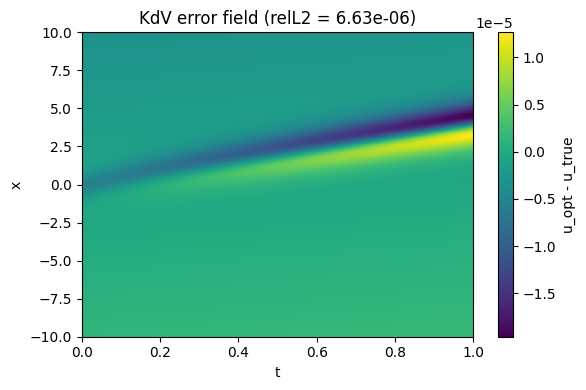

In [34]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1) Recreate the KdV problem (your existing function)
# ---------------------------------------------------------
def create_kdv_problem():
    x, t = sp.symbols("x t")
    k  = 1.0
    x0 = 0.0
    c  = 4.0 * k**2

    # Manufactured 1-soliton solution
    u_true = 2.0 * k**2 / sp.cosh(k * (x - c * t - x0))**2
    u0     = sp.simplify(u_true.subs(t, 0.0))

    problem = {
        "problem_type": "KdV-1Soliton-1D",
        "operators": "ut + 6*u*ux + uxxx",
        "F": "0",
        "initial_condition": [
            f"u(x, t=0) = {sp.simplify(u0)}"
        ],
        "boundary_conditions": [],
        "mesh": {
            "x": {"start": -10.0, "end": 10.0, "points": 256},
            "t": {"start": 0.0,   "end":  1.0, "points": 128},
        },
        "parameters": {},
        # store the true solution as string for later use
        "true_solution": str(sp.simplify(u_true)),
    }
    return problem

kdv_problem = create_kdv_problem()

# ---------------------------------------------------------
# 2) Put your optimized expression here
#    (string exactly as printed by JAX, with ^ for powers OK)
# ---------------------------------------------------------


# ---------------------------------------------------------
# 3) Utility to turn a string expr(x,t) into a NumPy callable
# ---------------------------------------------------------
def make_numpy_fn(expr_str):
    x, t = sp.symbols("x t")
    expr = sp.sympify(expr_str.replace("^", "**"))
    return sp.lambdify((x, t), expr, "numpy")

u_true_fn = make_numpy_fn(kdv_problem["true_solution"])
u_opt_fn  = make_numpy_fn(string)

# ---------------------------------------------------------
# 4) Build the (x,t) mesh from the problem definition
# ---------------------------------------------------------
x_cfg = kdv_problem["mesh"]["x"]
t_cfg = kdv_problem["mesh"]["t"]

xs = np.linspace(x_cfg["start"], x_cfg["end"], x_cfg["points"])
ts = np.linspace(t_cfg["start"], t_cfg["end"], t_cfg["points"])

X, T = np.meshgrid(xs, ts, indexing="ij")

# ---------------------------------------------------------
# 5) Evaluate fields and compute relative L2 error
# ---------------------------------------------------------
U_true = u_true_fn(X, T)
U_opt  = u_opt_fn(X, T)

# Make sure we have floats and no NaNs/Infs
U_true = np.asarray(U_true, dtype=float)
U_opt  = np.asarray(U_opt,  dtype=float)

# mask out any NaNs just in case
mask = np.isfinite(U_true) & np.isfinite(U_opt)
U_true_masked = U_true[mask]
U_opt_masked  = U_opt[mask]

num = np.sqrt(np.mean((U_opt_masked - U_true_masked)**2))
den = np.sqrt(np.mean(U_true_masked**2)) + 1e-16
relL2 = num / den

print(f"Relative L2 error (KdV, optimized vs true): {relL2:.6e}")

# ---------------------------------------------------------
# 6) Plot the error field u_opt - u_true
# ---------------------------------------------------------
err = U_opt - U_true

plt.figure(figsize=(6, 4))
im = plt.imshow(
    err,
    extent=[ts[0], ts[-1], xs[0], xs[-1]],
    origin="lower",
    aspect="auto"
)
plt.colorbar(im, label="u_opt - u_true")
plt.xlabel("t")
plt.ylabel("x")
plt.title(f"KdV error field (relL2 = {relL2:.2e})")
plt.tight_layout()
plt.show()


## 2-D Shallow Water Equations (main result, §4.1)

Three coupled fields: `ρ(x,y,t)`, `Sₓ(x,y)`, `Sᵧ(x,y)`.

**Key insight:** the Gaussian-envelope structure `exp(−r²/σ(1+t))` lives in the  
SPATIOTEMPORAL_3D cluster. Use **≥ 20 subclusters** to reliably sample it.

Run `scripts/discover.py --seed 888` for the full Stage I sweep,  
then `scripts/optimize.py` for Stage II JAX parameter refinement.

In [ ]:
# BEST SIGS CONFIG FOR SHALLOW WATER (based on hyperparam sweep)
# ================================================================

# For RHO: Current config (2 SPATIOTEMPORAL + 6 TEMPORAL with multiply)
# Gets: Wave ✓ + Decay ✓ + Gaussian envelope (needs SPATIOTEMPORAL_3D subclusters >= 20)
rho_config = {
    'categories': {
        'SPATIOTEMPORAL_3D': 20,  # 20 subclusters (needed for Gaussian envelope)
        'TEMPORAL_1D': 6,        # 6 subclusters  
    },
    'instances': {
        'SPATIOTEMPORAL_3D': 2,  # 2 factors per expression
        'TEMPORAL_1D': 1,        # 1 factor per expression
    },
    'operator': '*',  # Multiply
}

# For VELOCITY: Spatial multiply (BEST - 33% radial success)
# Gets: x/sqrt(r²) and y/sqrt(r²) patterns at 33% rate
velocity_config = {
    'categories': {
        'SPATIAL_2D': 100,  # Many subclusters for diversity
    },
    'instances': {
        'SPATIAL_2D': 2,  # 2 factors - key for radial forms!
    },
    'operator': '*',  # Multiply (not add!)
}

print("Best SIGS hyperparameters for shallow water:")
print(f"Rho: {rho_config}")
print(f"Velocity: {velocity_config}")
print()
print("Expected success rates:")
print("  - Wave structure: 100%")
print("  - Time decay: 60-70%")
print("  - Gaussian envelope: ~20-30% with SPATIOTEMPORAL_3D subclusters=20+")
print("  - Radial velocity: 33%")
print()
print("Recommendation: Increase SPATIOTEMPORAL_3D subclusters to 20+ for Gaussian envelope discovery")